# Quijote 2LPT Minimal Pipeline

最小链路：1) 批量生成/复用 white noise；2) 批量生成 psi1 与 q_init；3) 单 seed 做指标与功率谱可视化。

## Step 1. Batch White Noise

In [1]:
from pathlib import Path
import shutil
import subprocess
import os
import concurrent.futures as cf

# 选择目录: 'fiducial' 或 'fiducial_LR'
CATALOG_NAME = 'fiducial_LR'
ROOT_BASE = Path('/pscratch/sd/l/liuyh15/Quijote') / CATALOG_NAME

# white-noise 批量生成设置
BATCH_GENERATE_WN_FOR_ALL_SEEDS = True
BATCH_SKIP_EXISTING_WN = True
OVERWRITE_WN = False
RESET_WN_DIR_BEFORE_RUN = False
BATCH_WN_PARALLEL = True
BATCH_WN_MAX_WORKERS = 10

QUIJOTE_ROOT = Path('/global/homes/l/liuyh15/WorkSpace/Quijote')
LPTIC_EXE = QUIJOTE_ROOT / '2lpt' / '2LPTic'

if not LPTIC_EXE.exists():
    raise FileNotFoundError(f'2LPTic executable not found: {LPTIC_EXE}')

def _list_existing_seeds(root_base: Path):
    seeds = []
    for p in sorted(root_base.iterdir()):
        if not p.is_dir() or (not p.name.isdigit()):
            continue
        if (p / 'ICs' / '2LPT.param').exists():
            seeds.append(int(p.name))
    return seeds

def set_or_append(lines_in, key, value):
    out = []
    found = False
    for line in lines_in:
        s = line.strip()
        if s and not s.startswith('%') and s.split()[0] == key:
            out.append(f'{key}    {value}')
            found = True
        else:
            out.append(line)
    if not found:
        out.append(f'{key}    {value}')
    return out

def get_value(lines_in, key):
    for line in lines_in:
        s = line.strip()
        if not s or s.startswith('%'):
            continue
        p = s.split()
        if len(p) > 1 and p[0] == key:
            return p[1]
    return None

def resolve_resource_path(src_param, raw_value):
    p = Path(raw_value)
    if p.is_absolute() and p.exists():
        return p
    cands = [
        (src_param.parent / p).resolve(),
        (QUIJOTE_ROOT / p).resolve(),
        (QUIJOTE_ROOT / '2lpt' / p).resolve(),
        (QUIJOTE_ROOT / 'CAMB_TABLES' / p.name).resolve(),
        (QUIJOTE_ROOT / '2lpt' / 'GLASS' / p.name).resolve(),
    ]
    for c in cands:
        if c.exists():
            return c
    return cands[0]

def generate_white_noise_for_seed(seed_i: int):
    root = ROOT_BASE / str(seed_i)
    wn_dir = root / 'wn'
    ics_dir = root / 'ICs'
    src_param = ics_dir / '2LPT.param'
    dst_param = wn_dir / '2LPT_wn.param'
    white_noise_file = wn_dir / 'white_noise.npz'

    if not src_param.exists():
        raise FileNotFoundError(f'source param not found: {src_param}')

    if RESET_WN_DIR_BEFORE_RUN and wn_dir.exists():
        print(f'[cleanup][seed {seed_i}] remove {wn_dir}')
        shutil.rmtree(wn_dir)
    wn_dir.mkdir(parents=True, exist_ok=True)

    if BATCH_SKIP_EXISTING_WN and white_noise_file.exists() and dst_param.exists() and (not OVERWRITE_WN):
        print(f'[seed {seed_i}] skip: white noise exists')
        return False, white_noise_file

    # 写 white-noise-only param
    lines = src_param.read_text(encoding='utf-8').replace('\r\n', '\n').splitlines()
    lines = set_or_append(lines, 'OutputDir', str(wn_dir))
    lines = set_or_append(lines, 'FileBase', 'ics')
    lines = set_or_append(lines, 'UseWhiteNoiseInput', '0')
    lines = set_or_append(lines, 'ExportWhiteNoiseOnly', '1')
    lines = set_or_append(lines, 'WhiteNoiseFile', str(white_noise_file))

    for key in ('FileWithInputSpectrum', 'GlassFile'):
        v = get_value(lines, key)
        if v is not None:
            lines = set_or_append(lines, key, str(resolve_resource_path(src_param, v)))

    dst_param.write_text('\n'.join(lines) + '\n', encoding='utf-8')

    if OVERWRITE_WN and white_noise_file.exists():
        white_noise_file.unlink()

    cmd = [str(LPTIC_EXE), str(dst_param)]
    env = dict(os.environ)
    env['MPICH_GPU_SUPPORT_ENABLED'] = '0'
    print(f'[seed {seed_i}] run:', ' '.join(cmd))

    with subprocess.Popen(
        cmd,
        cwd=str(wn_dir),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    ) as proc:
        if proc.stdout is not None:
            for line in proc.stdout:
                print(f'[seed {seed_i}] {line}', end='')
        rc = proc.wait()

    if rc != 0:
        raise RuntimeError(f'2LPTic failed with return code {rc} for seed={seed_i}')
    if not white_noise_file.exists():
        raise FileNotFoundError(f'white noise was not produced: {white_noise_file}')

    return True, white_noise_file

def _run_wn_seed(seed_i: int):
    row = {'seed': seed_i, 'generated': False, 'white_noise': '', 'error': ''}
    try:
        generated, wn_file = generate_white_noise_for_seed(seed_i)
        row['generated'] = bool(generated)
        row['white_noise'] = str(wn_file)
    except Exception as e:
        row['error'] = str(e)
        print(f'[seed {seed_i}] fail:', e)
    return row

# 批量生成 wn（所有已有 seeds）
if BATCH_GENERATE_WN_FOR_ALL_SEEDS:
    seeds = _list_existing_seeds(ROOT_BASE)
    print(f'[batch wn] catalog={CATALOG_NAME}, seeds={seeds}')

    wn_rows = []
    use_parallel = BATCH_WN_PARALLEL and (BATCH_WN_MAX_WORKERS > 1) and (len(seeds) > 1)

    if use_parallel:
        workers = min(BATCH_WN_MAX_WORKERS, len(seeds))
        print(f'[batch wn] parallel enabled, workers={workers}')
        with cf.ThreadPoolExecutor(max_workers=workers) as ex:
            futs = {ex.submit(_run_wn_seed, s): s for s in seeds}
            for fut in cf.as_completed(futs):
                wn_rows.append(fut.result())
    else:
        print('[batch wn] serial mode')
        for seed_i in seeds:
            wn_rows.append(_run_wn_seed(seed_i))

    wn_rows.sort(key=lambda r: r['seed'])
    wn_ok = [r for r in wn_rows if not r['error']]
    wn_fail = [r for r in wn_rows if r['error']]
    print('\n[batch wn summary]')
    print('total:', len(wn_rows), 'ok:', len(wn_ok), 'fail:', len(wn_fail))
    print('generated:', sum(int(r['generated']) for r in wn_rows), 'skipped:', len(wn_ok) - sum(int(r['generated']) for r in wn_rows))
    if wn_fail:
        print('failed seeds:', [r['seed'] for r in wn_fail])

# 仅用于后续单 seed 展示/检查，不影响上面的全 seed wn 生成
SEED = 0
ROOT = ROOT_BASE / str(SEED)
WN_DIR = ROOT / 'wn'
ICS_DIR = ROOT / 'ICs'
DST_PARAM = WN_DIR / '2LPT_wn.param'
WHITE_NOISE_FILE = WN_DIR / 'white_noise.npz'
print(f'\n[single-seed context] catalog={CATALOG_NAME}, seed={SEED}, wn={WHITE_NOISE_FILE}')

## Step 2. Batch psi1 + q_init

In [2]:
from pathlib import Path
import sys
import importlib
import numpy as np

TESTS_DIR = Path('/global/homes/l/liuyh15/WorkSpace/DDDF/src')
if str(TESTS_DIR) not in sys.path:
    sys.path.insert(0, str(TESTS_DIR))

_2LPT = importlib.import_module('2LPT')
n2 = importlib.reload(_2LPT)

BATCH_FORCE_NMESH = None
BATCH_SKIP_EXISTING_PSI_QINIT = True

def _list_existing_seeds(root_base: Path):
    seeds = []
    for p in sorted(root_base.iterdir()):
        if p.is_dir() and p.name.isdigit() and (p / 'ICs' / '2LPT.param').exists():
            seeds.append(int(p.name))
    return seeds

seed_list = _list_existing_seeds(ROOT_BASE)
print(f'[psi1/q_init batch] catalog={CATALOG_NAME}, seeds={seed_list}')

psiq_rows = []
for seed_i in seed_list:
    row = {'seed': seed_i, 'psi1_file': '', 'qinit_file': '', 'generated': False, 'error': ''}
    try:
        root_i = ROOT_BASE / str(seed_i)
        wn_dir_i = root_i / 'wn'
        tag_i = f'seed{seed_i:03d}'
        psi1_candidates = sorted(wn_dir_i.glob(f'psi1_grid_z127_{tag_i}_n*.npz'))
        qinit_candidates = sorted(wn_dir_i.glob(f'q_init_{tag_i}_n*.npz'))

        if BATCH_SKIP_EXISTING_PSI_QINIT and psi1_candidates and qinit_candidates:
            psi1_file_i = psi1_candidates[-1]
            qinit_file_i = qinit_candidates[-1]
            print(f'[seed {seed_i}] skip existing: {psi1_file_i.name}, {qinit_file_i.name}')
        else:
            paths_i = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)
            psi1_file_i, qinit_file_i = n2.save_psi1_and_qinit_for_seed(
                paths_i,
                force_nmesh=BATCH_FORCE_NMESH,
                output_tag=tag_i,
            )
            row['generated'] = True
            print(f'[seed {seed_i}] generated: {Path(psi1_file_i).name}, {Path(qinit_file_i).name}')

        row['psi1_file'] = str(psi1_file_i)
        row['qinit_file'] = str(qinit_file_i)
    except Exception as e:
        row['error'] = str(e)
        print(f'[seed {seed_i}] fail: {e}')
    psiq_rows.append(row)

psiq_rows.sort(key=lambda r: r['seed'])
psiq_ok = [r for r in psiq_rows if not r['error']]
psiq_fail = [r for r in psiq_rows if r['error']]

print('\n[psi1/q_init summary]')
print('total:', len(psiq_rows), 'ok:', len(psiq_ok), 'fail:', len(psiq_fail))
print('generated:', sum(int(r['generated']) for r in psiq_rows), 'reused:', len(psiq_ok) - sum(int(r['generated']) for r in psiq_rows))
if psiq_fail:
    print('failed seeds:', [r['seed'] for r in psiq_fail])

# 为后续“特定 seed 对比”提供默认 seed
if psiq_ok:
    DEFAULT_COMPARE_SEED = int(psiq_ok[0]['seed'])
    print(f'default compare seed: {DEFAULT_COMPARE_SEED}')

## Step 3. One-Seed Validate

In [4]:
from pathlib import Path
from pprint import pprint
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import Pk_library as PKL

# 对齐粒子后做比较，并输出每一步耗时。
COMPARE_SEED = None
COMPARE_MAX_FILES = 1
Z0_POWER_MAX_FILES = None
GRID = None  # None -> infer from q_init particle resolution

t_start = perf_counter()
t_prev = t_start


def log_step(name: str):
    global t_prev
    t_now = perf_counter()
    print(f"[timing] {name:<40s} step={t_now - t_prev:7.3f}s  total={t_now - t_start:7.3f}s")
    t_prev = t_now


if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows is missing. Please run cell 5 first.')
log_step('check globals')

ok_rows = [r for r in psiq_rows if not r['error']]
if not ok_rows:
    raise RuntimeError('No successful seed in psiq_rows.')
log_step('filter successful seeds')

if COMPARE_SEED is None:
    seed_i = int(ok_rows[0]['seed'])
else:
    target = [r for r in ok_rows if int(r['seed']) == int(COMPARE_SEED)]
    if not target:
        available = sorted(int(r['seed']) for r in ok_rows)
        raise RuntimeError(f'COMPARE_SEED={COMPARE_SEED} unavailable. Available seeds: {available}')
    seed_i = int(target[0]['seed'])

row = [r for r in ok_rows if int(r['seed']) == seed_i][0]
print(f'[compare] seed={seed_i}')
log_step('select seed row')

root_i = ROOT_BASE / str(seed_i)
paths = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)
psi1_file = Path(row['psi1_file'])
qinit_file = Path(row['qinit_file'])
log_step('resolve file paths')

qd = np.load(qinit_file)
q_init = qd['q_init'].astype(np.float32)
npart = int(q_init.shape[0])
nmesh_guess = int(round(npart ** (1.0 / 3.0)))
if nmesh_guess ** 3 != npart:
    raise RuntimeError(f'Cannot infer cubic mesh from npart={npart}')
if GRID is None:
    GRID = nmesh_guess
print(f'[compare] GRID={GRID} inferred from npart={npart}')
log_step('load q_init and infer GRID')

recon = n2.reconstruct_z127_displacement_only(
    psi1_file=psi1_file,
    qinit_file=qinit_file,
    param_file=paths.param_file,
)
box = float(recon['box'][0])
log_step('reconstruct z=127 positions')

z127_metrics = n2.compare_z127_positions(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    ic_ref=paths.ic_ref,
    box=box,
    max_files=COMPARE_MAX_FILES,
)
log_step('compare z=127 metrics (aligned)')

z0_metrics = n2.compare_with_snapshot_z0(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    snapshot_dir=paths.snapshot_z0,
    box=box,
    max_files=COMPARE_MAX_FILES,
)
log_step('compare z=0 metrics (aligned)')

print('\n[z=127 metrics]')
pprint(z127_metrics)
print('\n[z=0 metrics]')
pprint(z0_metrics)

# Power ratio at z=127 (aligned in n2.compare_power_spectrum_z127)
pk_cmp_z127 = n2.compare_power_spectrum_z127(
    recon_positions=recon['x_rec'],
    recon_ids=recon['ids'],
    ic_ref=paths.ic_ref,
    box=box,
    max_files=COMPARE_MAX_FILES,
    grid=GRID,
)
log_step('z=127 aligned CIC+PKL+ratio')

k127 = np.asarray(pk_cmp_z127['k_h_mpc'], dtype=np.float64)
ratio127 = np.asarray(pk_cmp_z127['pk_ratio'], dtype=np.float64)
m127 = np.isfinite(ratio127) & (k127 > 0)
log_step('build z=127 ratio arrays')

# Power ratio at z=0 from psi (aligned by particle id)
psi = np.load(psi1_file)
psi1x = psi['psi1_x'].astype(np.float32)
psi1y = psi['psi1_y'].astype(np.float32)
psi1z = psi['psi1_z'].astype(np.float32)
box_local = float(np.asarray(psi['box']).ravel()[0])
log_step('load psi1 fields')

psi2x, psi2y, psi2z = n2._build_psi2_from_psi1(psi1x, psi1y, psi1z, box_local)
log_step('build psi2 fields')

if 'dplus' in psi.files:
    dplus = float(np.asarray(psi['dplus']).ravel()[0])
    scale1 = dplus
    scale2 = dplus * dplus
else:
    scale1 = 1.0
    scale2 = 1.0

disp0_particles = n2._trilinear_interp_vector(
    q_init,
    scale1 * psi1x + scale2 * psi2x,
    scale1 * psi1y + scale2 * psi2y,
    scale1 * psi1z + scale2 * psi2z,
    box_local,
)
x0_pred = np.mod(q_init + disp0_particles, np.float32(box_local)).astype(np.float32)
ids_pred = np.arange(1, q_init.shape[0] + 1, dtype=np.uint32)
log_step('interpolate + build z=0 prediction')

z0_pos, z0_ids = n2._load_hdf5_particles(paths.snapshot_z0, max_files=Z0_POWER_MAX_FILES)
log_step('load z=0 reference particles')

sel_pred, sel_z0 = n2._match_particle_ids(ids_pred, z0_ids)
log_step('align z=0 particles by ID')

k0 = np.array([], dtype=np.float64)
ratio0 = np.array([], dtype=np.float64)
m0 = np.array([], dtype=bool)
delta_pred_z0 = None
delta_ref_z0 = None

if sel_pred.size > 0:
    pred_sel = x0_pred[sel_pred]
    z0_sel = z0_pos[sel_z0]

    delta_pred_z0 = n2._paint_cic_density(pred_sel, box=box_local, grid=GRID)
    log_step('CIC paint z=0 aligned prediction')

    delta_ref_z0 = n2._paint_cic_density(z0_sel, box=box_local, grid=GRID)
    log_step('CIC paint z=0 aligned reference')

    pk_pred_obj = PKL.Pk(delta_pred_z0, box_local, axis=0, MAS='CIC', threads=16, verbose=False)
    log_step('PKL Pk z=0 aligned prediction')

    pk_ref_obj = PKL.Pk(delta_ref_z0, box_local, axis=0, MAS='CIC', threads=16, verbose=False)
    log_step('PKL Pk z=0 aligned reference')

    k0 = np.asarray(pk_ref_obj.k3D, dtype=np.float64) * 1000.0
    pk_ref0 = np.asarray(pk_ref_obj.Pk[:, 0], dtype=np.float64)
    pk_pred0 = np.asarray(pk_pred_obj.Pk[:, 0], dtype=np.float64)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio0 = np.where(pk_ref0 > 1e-30, pk_pred0 / pk_ref0, np.nan)
    m0 = np.isfinite(ratio0) & (k0 > 0)
    log_step('build z=0 aligned ratio arrays')
else:
    print('[warning] no matched particle IDs between prediction and z=0 reference')

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xscale('log')
if np.any(m127):
    ax.plot(k127[m127], ratio127[m127], lw=2.0, color='tab:blue', label=f'seed={seed_i}: P_rec(z=127)/P_ref(z=127)')
if np.any(m0):
    ax.plot(k0[m0], ratio0[m0], lw=2.0, ls='--', color='tab:orange', label=f'seed={seed_i}: P_py_from_psi(z=0)/P_nbody(z=0)')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\mathrm{A}}/P_{\mathrm{B}}$')
ax.set_ylim(0.0, 1.2)
ax.set_title(f'Power Spectrum Ratio (aligned, seed={seed_i}, GRID={GRID})')
ax.grid(alpha=0.3, which='both')
if np.any(m127) or np.any(m0):
    ax.legend()
plt.tight_layout()
plt.show()
log_step('plot')

if (delta_pred_z0 is not None) and (delta_ref_z0 is not None):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    img_py = np.mean(delta_pred_z0[:1], axis=0).T
    img_nb = np.mean(delta_ref_z0[:1], axis=0).T
    axes[0].imshow(img_py, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    axes[0].set_title(f'Python from psi (z=0, seed={seed_i})')
    axes[1].imshow(img_nb, cmap='gray_r', vmin=-1, vmax=3, origin='lower')
    axes[1].set_title(f'N-body (z=0, seed={seed_i})')
    plt.suptitle(f'Overdensity slice z=0 (seed={seed_i}, aligned)')
    plt.tight_layout()
    plt.show()
    log_step('plot z=0 overdensity slices')
else:
    print(f'z=0 overdensity slice skipped for seed={seed_i}.')

print(f"[timing] TOTAL{'':<35s}{perf_counter() - t_start:7.3f}s")

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# 比较 fiducial 与 fiducial_LR 在 seed=0 下，用 2LPT 预测得到的 z=0 overdensity。
# 注意：每个 catalog 使用各自原始粒子分辨率推断的 grid，不做重采样。
COMPARE_CATALOGS = ['fiducial', 'fiducial_LR']
COMPARE_SEED = 0

if 'n2' not in globals():
    import importlib
    _2LPT = importlib.import_module('2LPT')
    n2 = importlib.reload(_2LPT)

base_quijote = Path('/pscratch/sd/l/liuyh15/Quijote')
results = []

for catalog in COMPARE_CATALOGS:
    root_i = base_quijote / catalog / str(COMPARE_SEED)
    wn_dir = root_i / 'wn'
    tag = f'seed{COMPARE_SEED:03d}'

    psi_candidates = sorted(wn_dir.glob(f'psi1_grid_z127_{tag}_n*.npz'))
    qinit_candidates = sorted(wn_dir.glob(f'q_init_{tag}_n*.npz'))
    if (not psi_candidates) or (not qinit_candidates):
        raise FileNotFoundError(
            f'[{catalog}] missing psi1/q_init for seed={COMPARE_SEED} under {wn_dir}. '
            'Run Step 2 first to generate them.'
        )

    psi_file = psi_candidates[-1]
    qinit_file = qinit_candidates[-1]

    qd = np.load(qinit_file)
    q_init = qd['q_init'].astype(np.float32)
    npart = int(q_init.shape[0])
    grid_local = int(round(npart ** (1.0 / 3.0)))
    if grid_local ** 3 != npart:
        raise RuntimeError(f'[{catalog}] cannot infer cubic mesh from npart={npart}')

    psi = np.load(psi_file)
    psi1x = psi['psi1_x'].astype(np.float32)
    psi1y = psi['psi1_y'].astype(np.float32)
    psi1z = psi['psi1_z'].astype(np.float32)
    box_local = float(np.asarray(psi['box']).ravel()[0])

    psi2x, psi2y, psi2z = n2._build_psi2_from_psi1(psi1x, psi1y, psi1z, box_local)

    if 'dplus' in psi.files:
        dplus = float(np.asarray(psi['dplus']).ravel()[0])
        scale1 = dplus
        scale2 = dplus * dplus
    else:
        scale1 = 1.0
        scale2 = 1.0

    disp0_particles = n2._trilinear_interp_vector(
        q_init,
        scale1 * psi1x + scale2 * psi2x,
        scale1 * psi1y + scale2 * psi2y,
        scale1 * psi1z + scale2 * psi2z,
        box_local,
    )
    x0_pred = np.mod(q_init + disp0_particles, np.float32(box_local)).astype(np.float32)
    delta0 = n2._paint_cic_density(x0_pred, box=box_local, grid=grid_local)

    # 与 Step 3 保持一致，取第 0 个切片并沿一个轴平均得到 2D 可视化
    img = np.mean(delta0[:1], axis=0).T
    results.append({'catalog': catalog, 'grid': grid_local, 'img': img})

all_pixels = np.concatenate([r['img'].ravel() for r in results])
vmin = float(np.nanpercentile(all_pixels, 1.0))
vmax = float(np.nanpercentile(all_pixels, 99.0))

fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    ax.imshow(r['img'], cmap='gray_r', vmin=vmin, vmax=vmax, origin='lower')
    ax.set_title(f"{r['catalog']} (seed={COMPARE_SEED}, grid={r['grid']})")
    ax.set_xlabel('x index')
    ax.set_ylabel('y index')

plt.suptitle('2LPT-predicted z=0 overdensity comparison (original resolutions)')
plt.tight_layout()
plt.show()

## Step 4. ZA Velocity Divergence Power Spectrum

[vel] seed=0, npart=16777216, grid=256, box=1000000.0 kpc/h, dplus=101.0254
[vel] theta mode = mass
[vel] growth-rate model = exact dlnD/dlna
[vel] params from 2LPT_wn.param: Omega=0.3175, OmegaLambda=0.6825, InitTime=0.007812
[vel] (HubbleParam=0.6711 -- does NOT enter 2LPTic velocity formula)
[vel] _HUBBLE_CODE = 0.10000000 (H0=100 km/s/Mpc in code units)
[vel] hubble_a(z=127) = 81.599416 code units
[vel] f(z=127): 2LPTic=0.999999, used=1.000046
[vel] f(z=0): used=0.529762
[vel] vel_prefac(z=127) = 7.212768 (Gadget-stored vel / Psi in km/s)
[vel] vel_prefac(z=0)   = 5.351943 (includes dplus=101.0254)

[vel] interpolating ZA v(z=127) ...
[vel] t=5.9s  |v127_ZA| rms = 58.54 km/s
[vel] interpolating ZA v(z=0) ...
[vel] t=10.8s  |v0_ZA|  rms = 491.46 km/s
[vel] ZA displacement -> Eulerian positions (z=0) ...
[vel] t=15.7s
[vel] loading N-body velocities (z=127 ICs) ...
[vel] t=16.1s  n=16777216  |v_nb_127| rms = 58.55 km/s
[vel] loading N-body velocities (z=0 snapshot) ...
[vel] t=16.9s 

/tmp/ipykernel_200202/3356551098.py:183: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  return np.fft.irfftn(theta_k, s=(grid, grid, grid)).real.astype(np.float32)


[vel] t=19.3s  theta_ZA(z=127) rms = 0.0121
[vel] theta(z=127) N-body [mass] ...
[vel] t=21.3s  theta_nb(z=127) rms = 0.0118
[vel] theta(z=0) ZA [mass] ...
[vel] t=23.4s  theta_ZA(z=0) rms = 0.1681
[vel] theta(z=0) N-body [mass] ...
[vel] t=25.5s  theta_nb(z=0) rms = 0.3626
[vel] box for PKL = 1000.0 Mpc/h
[vel] computing P_thetatheta ...
[vel] t=28.4s  done
[vel] k range: 0.0089 ~ 1.390 h/Mpc
[vel] m127 points: 221, m0 points: 221
[vel] low-k mean ratio (z=127, k<=0.10): 1.0010
[vel] low-k mean ratio (z=0,   k<=0.10): 0.8663


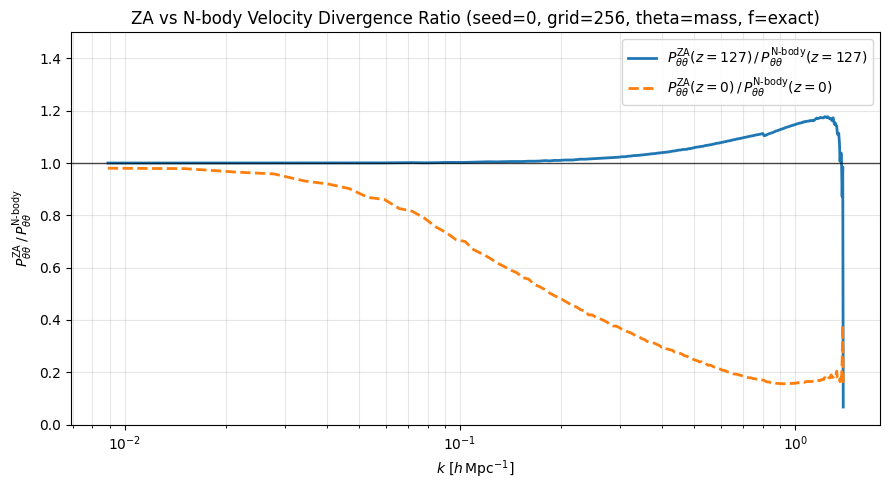

[vel] TOTAL 29.55s


In [6]:
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import h5py

# -- Settings -----------------------------------------------------------------
VEL_SEED = None   # None -> first available seed in psiq_rows
VEL_GRID = None   # None -> infer from npart^(1/3)
PKL_THREADS = 16
# Gadget stores v_stored = v_pec / sqrt(a); set True to correct
ASSUME_SQRT_A = True

# For better large-scale consistency at z=0, use mass-weighted theta by default.
#   'volume': theta = div(v)
#   'mass'  : theta = div[(1+delta) v] = div(p / rho_bar)
THETA_MODE = 'mass'

# Growth-rate choice used in ZA velocity prefactor.
# True  -> exact numerical f(a)=dlnD/dlna from n2._growth_factor
# False -> 2LPTic approximation f(a)=Omega(a)^0.6
USE_EXACT_GROWTH_RATE = True
GROWTH_RATE_REL_STEP = 1e-3

# Print mean ratio for k <= LOWK_MAX (h/Mpc)
LOWK_MAX = 0.10

# -- 2LPTic velocity formulas (reference) -------------------------------------
# From allvars.h:
#   HUBBLE = 3.2407789e-18 (H0 for h=1, in 1/s)
# From set_units():
#   UnitTime_in_s = UnitLength_in_cm / UnitVelocity_in_cm_per_s
#                 = 3.085678e21 / 1e5 = 3.085678e16 s
#   Hubble = HUBBLE * UnitTime_in_s ~= 0.1 [code units]
# From displacement_fields():
#   hubble_a = Hubble * sqrt(Omega/a^3 + (1-Omega-OmegaLambda)/a^2 + OmegaLambda)
#   vel_prefac = a * hubble_a * F_Omega(a)
#   vel_prefac /= sqrt(a)   # Gadget convention
#   => vel_prefac = sqrt(a) * hubble_a * F_Omega(a)
#   P[n].Vel[k] = dis[k] * vel_prefac   [km/s stored as v_pec/sqrt(a)]

# Hubble constant in code units (= H0 for h=1)
_HUBBLE_CODE = 3.2407789e-18 * (3.085678e21 / 1.0e5)  # ~= 0.1


def _hubble_a_code(a, omega_m, omega_l):
    """H(a) in 2LPTic code units."""
    return _HUBBLE_CODE * np.sqrt(
        omega_m / a**3 + (1.0 - omega_m - omega_l) / a**2 + omega_l
    )


def _F_Omega_2lpt(a, omega_m, omega_l):
    """2LPTic approximation f(a)=Omega(a)^0.6."""
    omega_a = omega_m / (omega_m + a * (1.0 - omega_m - omega_l) + a**3 * omega_l)
    return omega_a ** 0.6


def _growth_rate_exact(a, omega_m, omega_l, rel_step=1e-3):
    """Numerical f(a)=dlnD/dlna using n2._growth_factor."""
    a = float(a)
    if not (0.0 < a <= 1.0):
        raise ValueError(f'a must be in (0,1], got {a}')

    a_lo = max(1e-4, a * (1.0 - rel_step))
    a_hi = min(1.0, a * (1.0 + rel_step))

    if a_hi <= a_lo:
        a_lo = max(1e-4, a - rel_step)
        a_hi = min(1.0, a + rel_step)
        if a_hi <= a_lo:
            raise RuntimeError(f'Cannot bracket growth derivative at a={a}')

    d_lo = float(n2._growth_factor(a_lo, omega_m, omega_l))
    d_hi = float(n2._growth_factor(a_hi, omega_m, omega_l))
    return float(np.log(d_hi / d_lo) / np.log(a_hi / a_lo))


def _f_growth(a, omega_m, omega_l):
    if USE_EXACT_GROWTH_RATE:
        return _growth_rate_exact(a, omega_m, omega_l, rel_step=GROWTH_RATE_REL_STEP)
    return _F_Omega_2lpt(a, omega_m, omega_l)


def _vel_prefac_za(a, omega_m, omega_l):
    """
    ZA velocity prefactor in Gadget-storage convention:
        vel_prefac = sqrt(a) * H(a) * f(a)
    v_stored = Psi * vel_prefac
    v_pec    = v_stored * sqrt(a)
    """
    return np.sqrt(a) * _hubble_a_code(a, omega_m, omega_l) * _f_growth(a, omega_m, omega_l)


# -- Helper: load positions + velocities from Gadget HDF5 ---------------------
def _load_hdf5_pos_vel(path):
    files = [path] if path.is_file() else sorted(path.glob('*.hdf5'))
    pos_all, vel_all = [], []
    for fp in files:
        with h5py.File(fp, 'r') as h5:
            g = 'PartType1' if 'PartType1' in h5 else 'PartType0'
            pos_all.append(h5[f'{g}/Coordinates'][:].astype(np.float32))
            vel_all.append(h5[f'{g}/Velocities'][:].astype(np.float32))
    return np.concatenate(pos_all, axis=0), np.concatenate(vel_all, axis=0)


# -- Helper: CIC paint with optional per-particle weights ---------------------
def _cic_weighted(positions, box, grid, weights=None):
    field = np.zeros((grid, grid, grid), dtype=np.float32)
    try:
        import MAS_library as MASL

        pos_c = np.ascontiguousarray(positions.astype(np.float32))
        if weights is None:
            MASL.MA(pos_c, field, float(box), 'CIC', verbose=False)
        else:
            MASL.MA(
                pos_c,
                field,
                float(box),
                'CIC',
                W=np.ascontiguousarray(weights.astype(np.float32)),
                verbose=False,
            )
    except Exception:
        cell = box / grid
        gx = (positions[:, 0] / cell) % grid
        gy = (positions[:, 1] / cell) % grid
        gz = (positions[:, 2] / cell) % grid
        i0 = np.floor(gx).astype(np.int64)
        i1 = (i0 + 1) % grid
        j0 = np.floor(gy).astype(np.int64)
        j1 = (j0 + 1) % grid
        k0 = np.floor(gz).astype(np.int64)
        k1 = (k0 + 1) % grid
        tx = (gx - i0).astype(np.float32)
        ty = (gy - j0).astype(np.float32)
        tz = (gz - k0).astype(np.float32)
        ww = weights.astype(np.float32) if weights is not None else np.ones(len(positions), dtype=np.float32)
        for ii, jj, kk, fac in [
            (i0, j0, k0, (1 - tx) * (1 - ty) * (1 - tz)),
            (i1, j0, k0, tx * (1 - ty) * (1 - tz)),
            (i0, j1, k0, (1 - tx) * ty * (1 - tz)),
            (i0, j0, k1, (1 - tx) * (1 - ty) * tz),
            (i1, j1, k0, tx * ty * (1 - tz)),
            (i1, j0, k1, tx * (1 - ty) * tz),
            (i0, j1, k1, (1 - tx) * ty * tz),
            (i1, j1, k1, tx * ty * tz),
        ]:
            np.add.at(field, (ii, jj, kk), ww * fac)
    return field


# -- Helper: theta from painted fields ----------------------------------------
def _compute_theta(positions, vx, vy, vz, box, grid, mode='mass'):
    """
    mode='volume': theta = div(v)
    mode='mass'  : theta = div[(1+delta) v] = div(p / rho_bar)
    """
    rho = _cic_weighted(positions, box, grid)
    mom_x = _cic_weighted(positions, box, grid, weights=vx)
    mom_y = _cic_weighted(positions, box, grid, weights=vy)
    mom_z = _cic_weighted(positions, box, grid, weights=vz)

    if mode == 'volume':
        rho_safe = np.where(rho > 0, rho, 1.0)
        fx = (mom_x / rho_safe).astype(np.float64)
        fy = (mom_y / rho_safe).astype(np.float64)
        fz = (mom_z / rho_safe).astype(np.float64)
    elif mode == 'mass':
        rho_bar = float(np.mean(rho, dtype=np.float64))
        if rho_bar <= 0:
            raise RuntimeError(f'Non-positive rho_bar={rho_bar}')
        inv_rho_bar = 1.0 / rho_bar
        fx = (mom_x * inv_rho_bar).astype(np.float64)
        fy = (mom_y * inv_rho_bar).astype(np.float64)
        fz = (mom_z * inv_rho_bar).astype(np.float64)
    else:
        raise ValueError(f"Unknown theta mode '{mode}', choose from ['volume', 'mass']")

    kx, ky, kz = n2._kgrid(box, grid)
    theta_k = 1j * (kx * np.fft.rfftn(fx) + ky * np.fft.rfftn(fy) + kz * np.fft.rfftn(fz))
    return np.fft.irfftn(theta_k, s=(grid, grid, grid)).real.astype(np.float32)


# -- Helper: P_thetatheta(k), k in h/Mpc --------------------------------------
def _pk_theta(theta, box_mpc_h):
    try:
        import Pk_library as PKL

        pk_obj = PKL.Pk(
            theta.astype(np.float32),
            float(box_mpc_h),
            axis=0,
            MAS='CIC',
            threads=PKL_THREADS,
            verbose=False,
        )
        return np.asarray(pk_obj.k3D, dtype=np.float64), np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
    except Exception:
        k, pk = n2._pk_numpy(theta, box_mpc_h)
        return k, pk


def _lowk_mean_ratio(k, ratio, kmax):
    m = np.isfinite(ratio) & (k > 0) & (k <= kmax)
    if not np.any(m):
        return np.nan
    return float(np.nanmean(ratio[m]))


# -- Select seed ---------------------------------------------------------------
t0 = perf_counter()
if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows not found. Run cell 5 first.')
if 'n2' not in globals():
    raise RuntimeError('n2 module not found. Run cell 5 first.')

ok_vel = [r for r in psiq_rows if not r['error']]
if not ok_vel:
    raise RuntimeError('No successful seeds in psiq_rows.')

if VEL_SEED is None:
    seed_vel = int(ok_vel[0]['seed'])
else:
    match = [r for r in ok_vel if int(r['seed']) == VEL_SEED]
    if not match:
        raise RuntimeError(f'VEL_SEED={VEL_SEED} not found in psiq_rows.')
    seed_vel = int(match[0]['seed'])

row_vel = next(r for r in ok_vel if int(r['seed']) == seed_vel)
psi1_file_vel = Path(row_vel['psi1_file'])
qinit_file_vel = Path(row_vel['qinit_file'])

# -- Load ZA arrays ------------------------------------------------------------
psi_vel = np.load(psi1_file_vel)
qd_vel = np.load(qinit_file_vel)
psi1x_vel = psi_vel['psi1_x'].astype(np.float32)
psi1y_vel = psi_vel['psi1_y'].astype(np.float32)
psi1z_vel = psi_vel['psi1_z'].astype(np.float32)
q_vel = qd_vel['q_init'].astype(np.float32)
box_vel = float(np.asarray(psi_vel['box']).ravel()[0])
dplus_vel = float(np.asarray(psi_vel['dplus']).ravel()[0]) if 'dplus' in psi_vel.files else 1.0

npart_vel = q_vel.shape[0]
nmesh_vel = int(round(npart_vel ** (1.0 / 3.0)))
if VEL_GRID is None:
    VEL_GRID = nmesh_vel

print(f'[vel] seed={seed_vel}, npart={npart_vel}, grid={VEL_GRID}, box={box_vel:.1f} kpc/h, dplus={dplus_vel:.4f}')
print(f'[vel] theta mode = {THETA_MODE}')
print(f"[vel] growth-rate model = {'exact dlnD/dlna' if USE_EXACT_GROWTH_RATE else 'Omega(a)^0.6'}")

# -- Read cosmology from 2LPT_wn.param ----------------------------------------
root_vel = ROOT_BASE / str(seed_vel)
paths_vel = n2.discover_seed_paths(preferred_root=root_vel, fallback_root=root_vel)
cfg_vel = n2.load_param_config(paths_vel.param_file)
raw_p = n2.parse_param_file(paths_vel.param_file)

om = cfg_vel['omega_m']
ol = cfg_vel['omega_l']
a_init_vel = cfg_vel['init_time']

print(f'[vel] params from {paths_vel.param_file.name}: Omega={om}, OmegaLambda={ol}, InitTime={a_init_vel:.6f}')
print(f"[vel] (HubbleParam={raw_p.get('HubbleParam', '?')} -- does NOT enter 2LPTic velocity formula)")
print(f'[vel] _HUBBLE_CODE = {_HUBBLE_CODE:.8f} (H0=100 km/s/Mpc in code units)')

# -- Velocity prefactors -------------------------------------------------------
a = a_init_vel
hubble_a_init = _hubble_a_code(a, om, ol)
f_init_2lpt = _F_Omega_2lpt(a, om, ol)
f_init_use = _f_growth(a, om, ol)
f0_use = _f_growth(1.0, om, ol)

# vp_* are Gadget-storage prefactors (v_stored = Psi * vp)
vp_z127 = _vel_prefac_za(a, om, ol)
# psi1 is stored at z_init amplitude, so multiply by dplus to map to z=0 displacement amplitude
vp_z0 = _vel_prefac_za(1.0, om, ol) * dplus_vel

print(f'[vel] hubble_a(z=127) = {hubble_a_init:.6f} code units')
print(f'[vel] f(z=127): 2LPTic={f_init_2lpt:.6f}, used={f_init_use:.6f}')
print(f'[vel] f(z=0): used={f0_use:.6f}')
print(f'[vel] vel_prefac(z=127) = {vp_z127:.6f} (Gadget-stored vel / Psi in km/s)')
print(f'[vel] vel_prefac(z=0)   = {vp_z0:.6f} (includes dplus={dplus_vel:.4f})')

# -- ZA velocities at particle Lagrangian positions ---------------------------
# Physical peculiar velocity for theta:
#   v_pec = v_stored * sqrt(a)
pec_scale_z127 = vp_z127 * np.sqrt(a)
pec_scale_z0 = vp_z0

print('\n[vel] interpolating ZA v(z=127) ...')
v127_za = n2._trilinear_interp_vector(
    q_vel,
    pec_scale_z127 * psi1x_vel,
    pec_scale_z127 * psi1y_vel,
    pec_scale_z127 * psi1z_vel,
    box_vel,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  |v127_ZA| rms = {np.sqrt((v127_za**2).sum(-1)).mean():.2f} km/s')

print('[vel] interpolating ZA v(z=0) ...')
v0_za = n2._trilinear_interp_vector(
    q_vel,
    pec_scale_z0 * psi1x_vel,
    pec_scale_z0 * psi1y_vel,
    pec_scale_z0 * psi1z_vel,
    box_vel,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  |v0_ZA|  rms = {np.sqrt((v0_za**2).sum(-1)).mean():.2f} km/s')

# -- ZA z=0 Eulerian positions -------------------------------------------------
print('[vel] ZA displacement -> Eulerian positions (z=0) ...')
disp_z0_vel = n2._trilinear_interp_vector(
    q_vel,
    dplus_vel * psi1x_vel,
    dplus_vel * psi1y_vel,
    dplus_vel * psi1z_vel,
    box_vel,
)
x0_vel = np.mod(q_vel + disp_z0_vel, np.float32(box_vel)).astype(np.float32)
print(f'[vel] t={perf_counter()-t0:.1f}s')

# -- N-body reference velocities -----------------------------------------------
print('[vel] loading N-body velocities (z=127 ICs) ...')
nb_pos127, nb_vel127 = _load_hdf5_pos_vel(paths_vel.ic_ref)
if ASSUME_SQRT_A:
    nb_vel127 = nb_vel127 * np.float32(np.sqrt(a_init_vel))
print(
    f'[vel] t={perf_counter()-t0:.1f}s  n={nb_pos127.shape[0]}  '
    f'|v_nb_127| rms = {np.sqrt((nb_vel127**2).sum(-1)).mean():.2f} km/s'
)

print('[vel] loading N-body velocities (z=0 snapshot) ...')
nb_pos0, nb_vel0 = _load_hdf5_pos_vel(paths_vel.snapshot_z0)
print(
    f'[vel] t={perf_counter()-t0:.1f}s  n={nb_pos0.shape[0]}  '
    f'|v_nb_0| rms = {np.sqrt((nb_vel0**2).sum(-1)).mean():.2f} km/s'
)

# -- theta fields --------------------------------------------------------------
print(f"[vel] theta(z=127) ZA [{THETA_MODE}] ...")
theta_127_za = _compute_theta(
    q_vel,
    v127_za[:, 0],
    v127_za[:, 1],
    v127_za[:, 2],
    box_vel,
    VEL_GRID,
    mode=THETA_MODE,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  theta_ZA(z=127) rms = {float(np.std(theta_127_za)):.4f}')

print(f"[vel] theta(z=127) N-body [{THETA_MODE}] ...")
theta_127_nb = _compute_theta(
    nb_pos127,
    nb_vel127[:, 0],
    nb_vel127[:, 1],
    nb_vel127[:, 2],
    box_vel,
    VEL_GRID,
    mode=THETA_MODE,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  theta_nb(z=127) rms = {float(np.std(theta_127_nb)):.4f}')

print(f"[vel] theta(z=0) ZA [{THETA_MODE}] ...")
theta_0_za = _compute_theta(
    x0_vel,
    v0_za[:, 0],
    v0_za[:, 1],
    v0_za[:, 2],
    box_vel,
    VEL_GRID,
    mode=THETA_MODE,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  theta_ZA(z=0) rms = {float(np.std(theta_0_za)):.4f}')

print(f"[vel] theta(z=0) N-body [{THETA_MODE}] ...")
theta_0_nb = _compute_theta(
    nb_pos0,
    nb_vel0[:, 0],
    nb_vel0[:, 1],
    nb_vel0[:, 2],
    box_vel,
    VEL_GRID,
    mode=THETA_MODE,
)
print(f'[vel] t={perf_counter()-t0:.1f}s  theta_nb(z=0) rms = {float(np.std(theta_0_nb)):.4f}')

# -- Power spectra P_thetatheta(k) --------------------------------------------
box_mpc_h = box_vel * 1e-3
print(f'[vel] box for PKL = {box_mpc_h:.1f} Mpc/h')
print('[vel] computing P_thetatheta ...')
k127_za, pk127_za = _pk_theta(theta_127_za, box_mpc_h)
k127_nb, pk127_nb = _pk_theta(theta_127_nb, box_mpc_h)
k0_za, pk0_za = _pk_theta(theta_0_za, box_mpc_h)
k0_nb, pk0_nb = _pk_theta(theta_0_nb, box_mpc_h)
print(f'[vel] t={perf_counter()-t0:.1f}s  done')
print(f'[vel] k range: {k127_za.min():.4f} ~ {k127_za.max():.3f} h/Mpc')

# -- Ratios -------------------------------------------------------------------
with np.errstate(divide='ignore', invalid='ignore'):
    ratio127 = np.where(pk127_nb > 1e-30, pk127_za / pk127_nb, np.nan)
    ratio0 = np.where(pk0_nb > 1e-30, pk0_za / pk0_nb, np.nan)

m127_v = np.isfinite(ratio127) & (k127_za > 0)
m0_v = np.isfinite(ratio0) & (k0_za > 0)
print(f'[vel] m127 points: {np.sum(m127_v)}, m0 points: {np.sum(m0_v)}')

lowk_127 = _lowk_mean_ratio(k127_za, ratio127, LOWK_MAX)
lowk_0 = _lowk_mean_ratio(k0_za, ratio0, LOWK_MAX)
print(f'[vel] low-k mean ratio (z=127, k<={LOWK_MAX:.2f}): {lowk_127:.4f}')
print(f'[vel] low-k mean ratio (z=0,   k<={LOWK_MAX:.2f}): {lowk_0:.4f}')

# -- Plot ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xscale('log')
if np.any(m127_v):
    ax.plot(
        k127_za[m127_v],
        ratio127[m127_v],
        lw=2,
        color='tab:blue',
        label=r'$P_{\theta\theta}^{\rm ZA}(z=127)\,/\,P_{\theta\theta}^{\rm N\text{-}body}(z=127)$',
    )
if np.any(m0_v):
    ax.plot(
        k0_za[m0_v],
        ratio0[m0_v],
        lw=2,
        color='tab:orange',
        ls='--',
        label=r'$P_{\theta\theta}^{\rm ZA}(z=0)\,/\,P_{\theta\theta}^{\rm N\text{-}body}(z=0)$',
    )
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\theta\theta}^{\rm ZA}\,/\,P_{\theta\theta}^{\rm N\text{-}body}$')
ax.set_ylim(0.0, 1.5)
ax.set_title(
    f'ZA vs N-body Velocity Divergence Ratio '
    f'(seed={seed_vel}, grid={VEL_GRID}, theta={THETA_MODE}, '
    f"f={'exact' if USE_EXACT_GROWTH_RATE else 'omega^0.6'})"
)
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print(f'[vel] TOTAL {perf_counter()-t0:.2f}s')

[vcomp] building velocity component fields and power ratios ...
[vcomp] x: low-k mean ratio z=127: 0.9979 | z=0: 0.9236
[vcomp] y: low-k mean ratio z=127: 0.9980 | z=0: 0.9206
[vcomp] z: low-k mean ratio z=127: 0.9979 | z=0: 0.9190


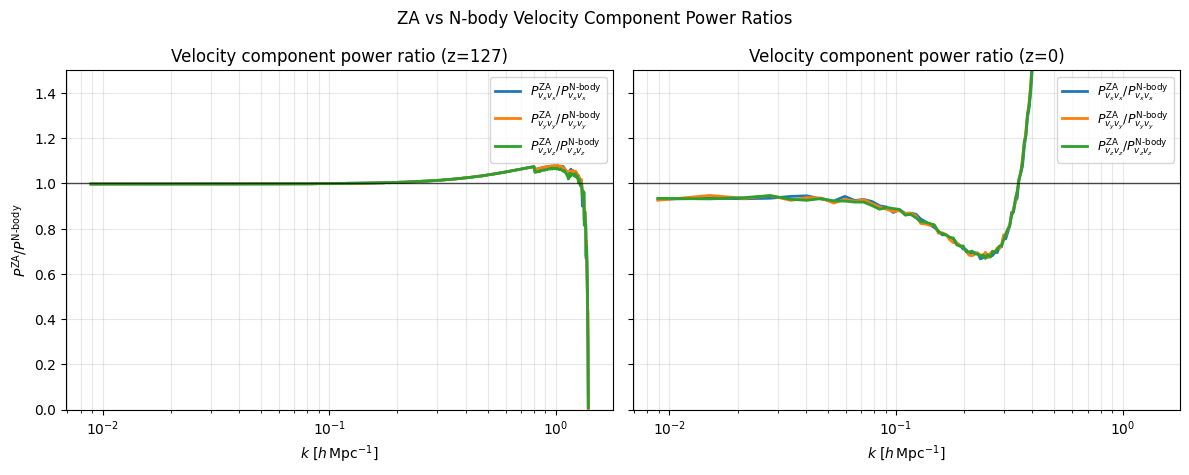

[vcomp] TOTAL 17.66s


In [7]:
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt

# Velocity component power: P_vxvx, P_vyvy, P_vzvz
# Reuse arrays from previous cell.
t0_comp = perf_counter()

required = [
    'q_vel', 'x0_vel', 'nb_pos127', 'nb_pos0',
    'v127_za', 'v0_za', 'nb_vel127', 'nb_vel0',
    'box_vel', 'VEL_GRID', 'LOWK_MAX'
]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f'Missing variables from previous cell: {missing}')

box_mpc_h = box_vel * 1e-3
comp_names = ['x', 'y', 'z']
comp_idx = [0, 1, 2]


def _velocity_component_field(positions, vcomp, box, grid):
    # Build Eulerian velocity field v_i(x) from particles via CIC painting.
    rho = _cic_weighted(positions, box, grid)
    mom = _cic_weighted(positions, box, grid, weights=vcomp)
    rho_safe = np.where(rho > 0, rho, 1.0)
    return (mom / rho_safe).astype(np.float32)


def _pk_field_3d(field, box_mpc_h):
    try:
        import Pk_library as PKL

        pk_obj = PKL.Pk(
            field.astype(np.float32),
            float(box_mpc_h),
            axis=0,
            MAS='CIC',
            threads=PKL_THREADS,
            verbose=False,
        )
        return np.asarray(pk_obj.k3D, dtype=np.float64), np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
    except Exception:
        return n2._pk_numpy(field, box_mpc_h)


print('[vcomp] building velocity component fields and power ratios ...')
ratio127 = {}
ratio0 = {}
kmask127 = {}
kmask0 = {}

for name, i in zip(comp_names, comp_idx):
    v127_za_f = _velocity_component_field(q_vel, v127_za[:, i], box_vel, VEL_GRID)
    v127_nb_f = _velocity_component_field(nb_pos127, nb_vel127[:, i], box_vel, VEL_GRID)
    v0_za_f = _velocity_component_field(x0_vel, v0_za[:, i], box_vel, VEL_GRID)
    v0_nb_f = _velocity_component_field(nb_pos0, nb_vel0[:, i], box_vel, VEL_GRID)

    k127_za, pk127_za = _pk_field_3d(v127_za_f, box_mpc_h)
    k127_nb, pk127_nb = _pk_field_3d(v127_nb_f, box_mpc_h)
    k0_za, pk0_za = _pk_field_3d(v0_za_f, box_mpc_h)
    k0_nb, pk0_nb = _pk_field_3d(v0_nb_f, box_mpc_h)

    with np.errstate(divide='ignore', invalid='ignore'):
        r127 = np.where(pk127_nb > 1e-30, pk127_za / pk127_nb, np.nan)
        r0 = np.where(pk0_nb > 1e-30, pk0_za / pk0_nb, np.nan)

    m127 = np.isfinite(r127) & (k127_za > 0)
    m0 = np.isfinite(r0) & (k0_za > 0)

    ratio127[name] = (k127_za, r127)
    ratio0[name] = (k0_za, r0)
    kmask127[name] = m127
    kmask0[name] = m0

    lowk127 = _lowk_mean_ratio(k127_za, r127, LOWK_MAX)
    lowk0 = _lowk_mean_ratio(k0_za, r0, LOWK_MAX)
    print(f'[vcomp] {name}: low-k mean ratio z=127: {lowk127:.4f} | z=0: {lowk0:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
colors = {'x': 'tab:blue', 'y': 'tab:orange', 'z': 'tab:green'}

ax = axes[0]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio127[name]
    m = kmask127[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm ZA}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^{\rm ZA}/P^{\rm N\text{-}body}$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=127)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

ax = axes[1]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio0[name]
    m = kmask0[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm ZA}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=0)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

plt.suptitle('ZA vs N-body Velocity Component Power Ratios')
plt.tight_layout()
plt.show()

print(f'[vcomp] TOTAL {perf_counter()-t0_comp:.2f}s')


[ZA-new] seed=0
[ZA-new] param file: /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/2LPT_wn.param
[ZA-new] Omega=0.317500, OmegaLambda=0.682500, a_init=0.00781250


/tmp/ipykernel_200202/1810136138.py:182: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return 2.5 * om * _E_of_a(float(a), om, ol) * np.trapz(integrand, aa)


[ZA-new] D(a_init)=9.898688e-03, D(1)=1.000000e+00, D(1)/D(a_init)=101.023494
[ZA-new] f(a_init)=1.000000, f(1)=0.529763
[ZA-new] H(a_init)=81.599414, H(1)=0.100000 [km/s/(kpc/h)]
[ZA-new] interpolate ZA v(z=127) ...
[ZA-new]  |v127_ZA| rms = 58.54 km/s
[ZA-new] interpolate ZA v(z=0) ...
[ZA-new]  |v0_ZA| rms = 491.45 km/s
[ZA-new] build ZA x(z=0) ...
[ZA-new] load N-body IC and z=0 velocities ...
[ZA-new] n(IC)=16777216, n(z0)=16777216, grid=256, box=1000000.0 kpc/h
[ZA-new] build component fields + power ratios ...
[ZA-new] x: low-k mean ratio z=127=0.9978 | z=0=0.9236
[ZA-new] y: low-k mean ratio z=127=0.9979 | z=0=0.9206
[ZA-new] z: low-k mean ratio z=127=0.9978 | z=0=0.9190


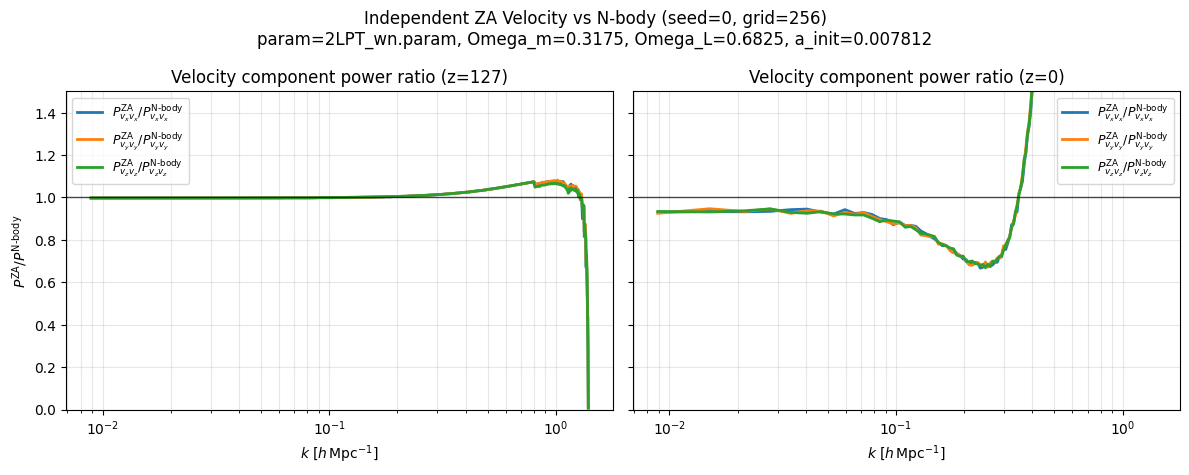

[ZA-new] TOTAL 36.35s


In [4]:
from pathlib import Path
from time import perf_counter
import importlib
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Independent ZA velocity calculation + component-power comparison
# (same comparison style as previous last cell)
ZA_VEL_SEED = None   # None -> first available successful seed
ZA_VEL_GRID = None   # None -> infer from npart^(1/3)
ZA_PKL_THREADS = 16
ZA_LOWK_MAX = 0.10
ZA_ASSUME_IC_SQRT_A = True  # IC files usually store v/sqrt(a)


def _strip_comment(line: str) -> str:
    if '%' in line:
        line = line[: line.index('%')]
    return line.strip()


def _parse_param_file(path: Path):
    vals = {}
    with path.open('r', encoding='utf-8') as f:
        for raw in f:
            line = _strip_comment(raw)
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                vals[parts[0]] = parts[1]
    return vals


def _find_wn_param(wn_dir: Path) -> Path:
    cands = sorted(wn_dir.glob('*.param'))
    if not cands:
        raise FileNotFoundError(f'No .param found in {wn_dir}')

    # Prefer 2LPT_wn*.param if present
    preferred = [p for p in cands if p.name.startswith('2LPT_wn')]
    if preferred:
        return preferred[0]
    return cands[0]


def _load_hdf5_pos_vel(path: Path):
    files = [path] if path.is_file() else sorted(path.glob('*.hdf5'))
    if not files:
        raise FileNotFoundError(f'No hdf5 files found under {path}')
    pos_all, vel_all = [], []
    for fp in files:
        with h5py.File(fp, 'r') as h5:
            g = 'PartType1' if 'PartType1' in h5 else 'PartType0'
            pos_all.append(h5[f'{g}/Coordinates'][:].astype(np.float32))
            vel_all.append(h5[f'{g}/Velocities'][:].astype(np.float32))
    return np.concatenate(pos_all, axis=0), np.concatenate(vel_all, axis=0)


def _cic_weighted(positions, box, grid, weights=None):
    field = np.zeros((grid, grid, grid), dtype=np.float32)
    try:
        import MAS_library as MASL

        pos_c = np.ascontiguousarray(positions.astype(np.float32))
        if weights is None:
            MASL.MA(pos_c, field, float(box), 'CIC', verbose=False)
        else:
            MASL.MA(
                pos_c,
                field,
                float(box),
                'CIC',
                W=np.ascontiguousarray(weights.astype(np.float32)),
                verbose=False,
            )
    except Exception:
        cell = box / grid
        gx = (positions[:, 0] / cell) % grid
        gy = (positions[:, 1] / cell) % grid
        gz = (positions[:, 2] / cell) % grid
        i0 = np.floor(gx).astype(np.int64)
        i1 = (i0 + 1) % grid
        j0 = np.floor(gy).astype(np.int64)
        j1 = (j0 + 1) % grid
        k0 = np.floor(gz).astype(np.int64)
        k1 = (k0 + 1) % grid
        tx = (gx - i0).astype(np.float32)
        ty = (gy - j0).astype(np.float32)
        tz = (gz - k0).astype(np.float32)
        ww = weights.astype(np.float32) if weights is not None else np.ones(len(positions), dtype=np.float32)

        for ii, jj, kk, fac in [
            (i0, j0, k0, (1 - tx) * (1 - ty) * (1 - tz)),
            (i1, j0, k0, tx * (1 - ty) * (1 - tz)),
            (i0, j1, k0, (1 - tx) * ty * (1 - tz)),
            (i0, j0, k1, (1 - tx) * (1 - ty) * tz),
            (i1, j1, k0, tx * ty * (1 - tz)),
            (i1, j0, k1, tx * (1 - ty) * tz),
            (i0, j1, k1, (1 - tx) * ty * tz),
            (i1, j1, k1, tx * ty * tz),
        ]:
            np.add.at(field, (ii, jj, kk), ww * fac)

    return field


def _velocity_component_field(positions, vcomp, box, grid):
    rho = _cic_weighted(positions, box, grid)
    mom = _cic_weighted(positions, box, grid, weights=vcomp)
    rho_safe = np.where(rho > 0, rho, 1.0)
    return (mom / rho_safe).astype(np.float32)


def _pk_field_numpy(field, box_mpc_h):
    n = int(field.shape[0])
    dk = np.fft.rfftn(field.astype(np.float64))
    power = (dk * np.conjugate(dk)).real * (box_mpc_h ** 3) / (n ** 6)

    dx = box_mpc_h / n
    kx = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)
    kkx, kky, kkz = np.meshgrid(kx, ky, kz, indexing='ij')
    kmag = np.sqrt(kkx ** 2 + kky ** 2 + kkz ** 2)

    kf = 2.0 * np.pi / box_mpc_h
    shell = np.rint(kmag / kf).astype(np.int64)
    valid = shell > 0

    shell_flat = shell[valid].ravel()
    p_flat = power[valid].ravel()
    k_flat = kmag[valid].ravel()

    p_sum = np.bincount(shell_flat, weights=p_flat)
    k_sum = np.bincount(shell_flat, weights=k_flat)
    cnt = np.bincount(shell_flat)

    good = cnt > 0
    k_out = k_sum[good] / cnt[good]
    p_out = p_sum[good] / cnt[good]
    return k_out.astype(np.float64), p_out.astype(np.float64)


def _pk_field_3d(field, box_mpc_h):
    try:
        import Pk_library as PKL

        pk_obj = PKL.Pk(
            field.astype(np.float32),
            float(box_mpc_h),
            axis=0,
            MAS='CIC',
            threads=ZA_PKL_THREADS,
            verbose=False,
        )
        return np.asarray(pk_obj.k3D, dtype=np.float64), np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
    except Exception:
        return _pk_field_numpy(field, box_mpc_h)


def _lowk_mean_ratio(k, ratio, kmax):
    m = np.isfinite(ratio) & (k > 0) & (k <= kmax)
    if not np.any(m):
        return np.nan
    return float(np.nanmean(ratio[m]))


# --- ZA background/growth from cosmology in wn/*.param ----------------------
def _E_of_a(a, om, ol):
    ok = 1.0 - om - ol
    return np.sqrt(om / a ** 3 + ok / a ** 2 + ol)


def _D_unnorm(a, om, ol, n_int=8192):
    # Growth integral: D(a) ∝ E(a) * ∫ da' / (a'^3 E(a')^3)
    a_min = 1.0e-5
    aa = np.geomspace(a_min, float(a), n_int)
    ee = _E_of_a(aa, om, ol)
    integrand = 1.0 / (aa ** 3 * ee ** 3)
    return 2.5 * om * _E_of_a(float(a), om, ol) * np.trapz(integrand, aa)


def _D_of_a(a, om, ol):
    d1 = _D_unnorm(1.0, om, ol)
    return float(_D_unnorm(float(a), om, ol) / d1)


def _f_growth(a, om, ol, rel_step=1.0e-3):
    a = float(a)
    a_lo = max(1.0e-4, a * (1.0 - rel_step))
    a_hi = min(1.0, a * (1.0 + rel_step))

    # Ensure valid finite-difference bracket near boundaries.
    if a_hi <= a_lo:
        if a >= 1.0:
            a_lo = max(1.0e-4, a * (1.0 - 2.0 * rel_step))
            a_hi = a
        else:
            a_lo = a
            a_hi = min(1.0, a * (1.0 + 2.0 * rel_step))

    d_lo = _D_of_a(a_lo, om, ol)
    d_hi = _D_of_a(a_hi, om, ol)
    return float(np.log(d_hi / d_lo) / np.log(a_hi / a_lo))


def _H_code(a, om, ol):
    # H0 = 100 km/s/(Mpc/h) = 0.1 km/s/(kpc/h)
    return 0.1 * _E_of_a(float(a), om, ol)


# --- Main --------------------------------------------------------------------
t0 = perf_counter()

if 'n2' not in globals():
    _2LPT = importlib.import_module('2LPT')
    n2 = importlib.reload(_2LPT)

if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows is missing. Run the psi1/q_init batch cell first.')
if 'ROOT_BASE' not in globals():
    raise RuntimeError('ROOT_BASE is missing. Run the setup cell first.')

ok_rows = [r for r in psiq_rows if not r['error']]
if not ok_rows:
    raise RuntimeError('No successful seed in psiq_rows.')

if ZA_VEL_SEED is None:
    seed_i = int(ok_rows[0]['seed'])
else:
    target = [r for r in ok_rows if int(r['seed']) == int(ZA_VEL_SEED)]
    if not target:
        av = sorted(int(r['seed']) for r in ok_rows)
        raise RuntimeError(f'ZA_VEL_SEED={ZA_VEL_SEED} unavailable. Available: {av}')
    seed_i = int(target[0]['seed'])

row = [r for r in ok_rows if int(r['seed']) == seed_i][0]
psi1_file = Path(row['psi1_file'])
qinit_file = Path(row['qinit_file'])
wn_dir = psi1_file.parent
param_file = _find_wn_param(wn_dir)
params = _parse_param_file(param_file)

om = float(params['Omega'])
ol = float(params['OmegaLambda'])
if 'InitTime' in params:
    a_init = float(params['InitTime'])
elif 'Redshift' in params:
    a_init = 1.0 / (1.0 + float(params['Redshift']))
else:
    raise KeyError(f'Neither InitTime nor Redshift found in {param_file}')

print(f'[ZA-new] seed={seed_i}')
print(f'[ZA-new] param file: {param_file}')
print(f'[ZA-new] Omega={om:.6f}, OmegaLambda={ol:.6f}, a_init={a_init:.8f}')

psi = np.load(psi1_file)
qd = np.load(qinit_file)
psi1x = psi['psi1_x'].astype(np.float32)
psi1y = psi['psi1_y'].astype(np.float32)
psi1z = psi['psi1_z'].astype(np.float32)
q_init = qd['q_init'].astype(np.float32)
box = float(np.asarray(psi['box']).ravel()[0])

npart = int(q_init.shape[0])
grid_local = int(round(npart ** (1.0 / 3.0)))
if grid_local ** 3 != npart:
    raise RuntimeError(f'Cannot infer cubic mesh from npart={npart}')
if ZA_VEL_GRID is None:
    ZA_VEL_GRID = grid_local

root_i = ROOT_BASE / str(seed_i)
paths = n2.discover_seed_paths(preferred_root=root_i, fallback_root=root_i)

# ZA growth mapping from stored psi(a_init) to psi(a)
D_init = _D_of_a(a_init, om, ol)
D_0 = _D_of_a(1.0, om, ol)
growth_ratio_0 = D_0 / D_init

f_init = _f_growth(a_init, om, ol)
f0 = _f_growth(1.0, om, ol)
H_init = _H_code(a_init, om, ol)
H0 = _H_code(1.0, om, ol)

print(f'[ZA-new] D(a_init)={D_init:.6e}, D(1)={D_0:.6e}, D(1)/D(a_init)={growth_ratio_0:.6f}')
print(f'[ZA-new] f(a_init)={f_init:.6f}, f(1)={f0:.6f}')
print(f'[ZA-new] H(a_init)={H_init:.6f}, H(1)={H0:.6f} [km/s/(kpc/h)]')

# v_pec(a) = a * H(a) * f(a) * Psi(a)
# psi1_* stores Psi(a_init), so Psi(1)=Psi(a_init)*D(1)/D(a_init)
vscale_127 = a_init * H_init * f_init
vscale_0 = 1.0 * H0 * f0 * growth_ratio_0

print('[ZA-new] interpolate ZA v(z=127) ...')
v127_za = n2._trilinear_interp_vector(
    q_init,
    vscale_127 * psi1x,
    vscale_127 * psi1y,
    vscale_127 * psi1z,
    box,
)
print(f'[ZA-new]  |v127_ZA| rms = {np.sqrt((v127_za ** 2).sum(-1)).mean():.2f} km/s')

print('[ZA-new] interpolate ZA v(z=0) ...')
v0_za = n2._trilinear_interp_vector(
    q_init,
    vscale_0 * psi1x,
    vscale_0 * psi1y,
    vscale_0 * psi1z,
    box,
)
print(f'[ZA-new]  |v0_ZA| rms = {np.sqrt((v0_za ** 2).sum(-1)).mean():.2f} km/s')

# ZA Eulerian positions at z=0 for velocity painting
print('[ZA-new] build ZA x(z=0) ...')
disp0 = n2._trilinear_interp_vector(
    q_init,
    growth_ratio_0 * psi1x,
    growth_ratio_0 * psi1y,
    growth_ratio_0 * psi1z,
    box,
)
x0_za = np.mod(q_init + disp0, np.float32(box)).astype(np.float32)

print('[ZA-new] load N-body IC and z=0 velocities ...')
nb_pos127, nb_vel127 = _load_hdf5_pos_vel(paths.ic_ref)
if ZA_ASSUME_IC_SQRT_A:
    nb_vel127 = nb_vel127 * np.float32(np.sqrt(a_init))
nb_pos0, nb_vel0 = _load_hdf5_pos_vel(paths.snapshot_z0)

print(f'[ZA-new] n(IC)={nb_pos127.shape[0]}, n(z0)={nb_pos0.shape[0]}, grid={ZA_VEL_GRID}, box={box:.1f} kpc/h')

box_mpc_h = box * 1.0e-3
comp_names = ['x', 'y', 'z']
colors = {'x': 'tab:blue', 'y': 'tab:orange', 'z': 'tab:green'}

ratio127 = {}
ratio0 = {}
mask127 = {}
mask0 = {}

print('[ZA-new] build component fields + power ratios ...')
for i, name in enumerate(comp_names):
    f127_za = _velocity_component_field(q_init, v127_za[:, i], box, ZA_VEL_GRID)
    f127_nb = _velocity_component_field(nb_pos127, nb_vel127[:, i], box, ZA_VEL_GRID)
    f0_za = _velocity_component_field(x0_za, v0_za[:, i], box, ZA_VEL_GRID)
    f0_nb = _velocity_component_field(nb_pos0, nb_vel0[:, i], box, ZA_VEL_GRID)

    k127_za, pk127_za = _pk_field_3d(f127_za, box_mpc_h)
    k127_nb, pk127_nb = _pk_field_3d(f127_nb, box_mpc_h)
    k0_za, pk0_za = _pk_field_3d(f0_za, box_mpc_h)
    k0_nb, pk0_nb = _pk_field_3d(f0_nb, box_mpc_h)

    with np.errstate(divide='ignore', invalid='ignore'):
        r127 = np.where(pk127_nb > 1e-30, pk127_za / pk127_nb, np.nan)
        r0 = np.where(pk0_nb > 1e-30, pk0_za / pk0_nb, np.nan)

    m127 = np.isfinite(r127) & (k127_za > 0)
    m0 = np.isfinite(r0) & (k0_za > 0)

    ratio127[name] = (k127_za, r127)
    ratio0[name] = (k0_za, r0)
    mask127[name] = m127
    mask0[name] = m0

    low127 = _lowk_mean_ratio(k127_za, r127, ZA_LOWK_MAX)
    low0 = _lowk_mean_ratio(k0_za, r0, ZA_LOWK_MAX)
    print(f'[ZA-new] {name}: low-k mean ratio z=127={low127:.4f} | z=0={low0:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

ax = axes[0]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio127[name]
    m = mask127[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm ZA}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^{\rm ZA}/P^{\rm N\text{-}body}$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=127)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

ax = axes[1]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio0[name]
    m = mask0[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm ZA}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=0)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

plt.suptitle(
    f'Independent ZA Velocity vs N-body (seed={seed_i}, grid={ZA_VEL_GRID})\n'
    f'param={param_file.name}, Omega_m={om:.4f}, Omega_L={ol:.4f}, a_init={a_init:.6f}'
)
plt.tight_layout()
plt.show()

print(f'[ZA-new] TOTAL {perf_counter() - t0:.2f}s')


[2LPT-new] seed=0
[2LPT-new] param=/pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/2LPT_wn.param
[2LPT-new] Omega_m=0.317500, Omega_L=0.682500, a_init=0.00781250
[2LPT-new] building psi2 from psi1 ...


/tmp/ipykernel_200202/2078001043.py:243: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  psi2x = np.fft.irfftn((-3.0 / 7.0) * 1j * kx * phi2_k, s=(n, n, n)).real.astype(np.float32)
/tmp/ipykernel_200202/2078001043.py:244: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  psi2y = np.fft.irfftn((-3.0 / 7.0) * 1j * ky * phi2_k, s=(n, n, n)).real.astype(np.float32)
/tmp/ipykernel_200202/2078001043.py:245: Deprecation

[2LPT-new] D(a_init)=9.898688e-03, r1(z0)=101.023494
[2LPT-new] dplus(file)=101.025389, |r1-dplus|=1.895e-03
[2LPT-new] f1(z127)=1.000000, f1(z0)=0.529763
[2LPT-new] f2(z127)=1.999999, f2(z0)=1.059525
[2LPT-new] interpolate v(z=127) ...
[2LPT-new] |v127_2LPT| rms = 58.54 km/s
[2LPT-new] interpolate v(z=0) ...
[2LPT-new] |v0_2LPT| rms = 508.73 km/s
[2LPT-new] build x(z=0) for Eulerian painting ...
[2LPT-new] load N-body IC and z=0 velocities ...
[2LPT-new] n(IC)=16777216, n(z0)=16777216, grid=256, box=1000000.0 kpc/h
[2LPT-new] build component fields + power ratios ...
[2LPT-new] x: low-k mean ratio z=127=0.9978 | z=0=0.8622
[2LPT-new] y: low-k mean ratio z=127=0.9979 | z=0=0.8631
[2LPT-new] z: low-k mean ratio z=127=0.9978 | z=0=0.8630


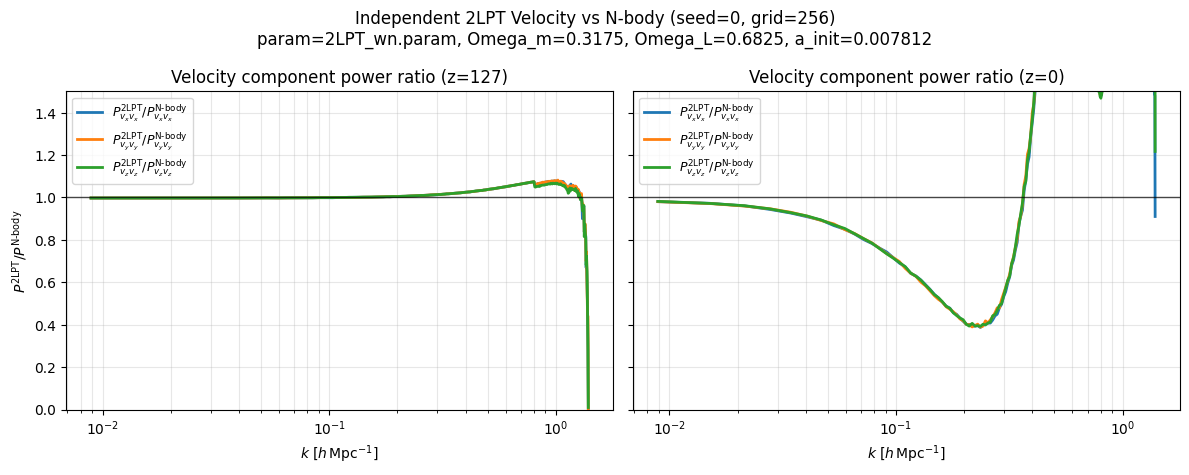

[2LPT-new] TOTAL 41.49s


In [9]:
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Independent 2LPT velocity (non-2LPTic) + same component-power comparison style
TWO_LPT_SEED = None
TWO_LPT_GRID = None
TWO_LPT_PKL_THREADS = 16
TWO_LPT_LOWK_MAX = 0.10
TWO_LPT_ASSUME_IC_SQRT_A = True


def _strip_comment(line: str) -> str:
    if '%' in line:
        line = line[: line.index('%')]
    return line.strip()


def _parse_param_file(path: Path):
    vals = {}
    with path.open('r', encoding='utf-8') as f:
        for raw in f:
            line = _strip_comment(raw)
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                vals[parts[0]] = parts[1]
    return vals


def _find_wn_param(wn_dir: Path) -> Path:
    cands = sorted(wn_dir.glob('*.param'))
    if not cands:
        raise FileNotFoundError(f'No .param found in {wn_dir}')
    preferred = [p for p in cands if p.name.startswith('2LPT_wn')]
    return preferred[0] if preferred else cands[0]


def _load_hdf5_pos_vel(path: Path):
    files = [path] if path.is_file() else sorted(path.glob('*.hdf5'))
    if not files:
        raise FileNotFoundError(f'No hdf5 files found under {path}')
    pos_all, vel_all = [], []
    for fp in files:
        with h5py.File(fp, 'r') as h5:
            g = 'PartType1' if 'PartType1' in h5 else 'PartType0'
            pos_all.append(h5[f'{g}/Coordinates'][:].astype(np.float32))
            vel_all.append(h5[f'{g}/Velocities'][:].astype(np.float32))
    return np.concatenate(pos_all, axis=0), np.concatenate(vel_all, axis=0)


def _cic_weighted(positions, box, grid, weights=None):
    field = np.zeros((grid, grid, grid), dtype=np.float32)
    try:
        import MAS_library as MASL

        pos_c = np.ascontiguousarray(positions.astype(np.float32))
        if weights is None:
            MASL.MA(pos_c, field, float(box), 'CIC', verbose=False)
        else:
            MASL.MA(
                pos_c,
                field,
                float(box),
                'CIC',
                W=np.ascontiguousarray(weights.astype(np.float32)),
                verbose=False,
            )
    except Exception:
        cell = box / grid
        gx = (positions[:, 0] / cell) % grid
        gy = (positions[:, 1] / cell) % grid
        gz = (positions[:, 2] / cell) % grid
        i0 = np.floor(gx).astype(np.int64)
        i1 = (i0 + 1) % grid
        j0 = np.floor(gy).astype(np.int64)
        j1 = (j0 + 1) % grid
        k0 = np.floor(gz).astype(np.int64)
        k1 = (k0 + 1) % grid
        tx = (gx - i0).astype(np.float32)
        ty = (gy - j0).astype(np.float32)
        tz = (gz - k0).astype(np.float32)
        ww = weights.astype(np.float32) if weights is not None else np.ones(len(positions), dtype=np.float32)

        for ii, jj, kk, fac in [
            (i0, j0, k0, (1 - tx) * (1 - ty) * (1 - tz)),
            (i1, j0, k0, tx * (1 - ty) * (1 - tz)),
            (i0, j1, k0, (1 - tx) * ty * (1 - tz)),
            (i0, j0, k1, (1 - tx) * (1 - ty) * tz),
            (i1, j1, k0, tx * ty * (1 - tz)),
            (i1, j0, k1, tx * (1 - ty) * tz),
            (i0, j1, k1, (1 - tx) * ty * tz),
            (i1, j1, k1, tx * ty * tz),
        ]:
            np.add.at(field, (ii, jj, kk), ww * fac)
    return field


def _velocity_component_field(positions, vcomp, box, grid):
    rho = _cic_weighted(positions, box, grid)
    mom = _cic_weighted(positions, box, grid, weights=vcomp)
    rho_safe = np.where(rho > 0, rho, 1.0)
    return (mom / rho_safe).astype(np.float32)


def _pk_field_numpy(field, box_mpc_h):
    n = int(field.shape[0])
    dk = np.fft.rfftn(field.astype(np.float64))
    power = (dk * np.conjugate(dk)).real * (box_mpc_h ** 3) / (n ** 6)

    dx = box_mpc_h / n
    kx = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)
    kkx, kky, kkz = np.meshgrid(kx, ky, kz, indexing='ij')
    kmag = np.sqrt(kkx ** 2 + kky ** 2 + kkz ** 2)

    kf = 2.0 * np.pi / box_mpc_h
    shell = np.rint(kmag / kf).astype(np.int64)
    valid = shell > 0

    shell_flat = shell[valid].ravel()
    p_flat = power[valid].ravel()
    k_flat = kmag[valid].ravel()

    p_sum = np.bincount(shell_flat, weights=p_flat)
    k_sum = np.bincount(shell_flat, weights=k_flat)
    cnt = np.bincount(shell_flat)

    good = cnt > 0
    k_out = k_sum[good] / cnt[good]
    p_out = p_sum[good] / cnt[good]
    return k_out.astype(np.float64), p_out.astype(np.float64)


def _pk_field_3d(field, box_mpc_h):
    try:
        import Pk_library as PKL

        pk_obj = PKL.Pk(
            field.astype(np.float32),
            float(box_mpc_h),
            axis=0,
            MAS='CIC',
            threads=TWO_LPT_PKL_THREADS,
            verbose=False,
        )
        return np.asarray(pk_obj.k3D, dtype=np.float64), np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
    except Exception:
        return _pk_field_numpy(field, box_mpc_h)


def _lowk_mean_ratio(k, ratio, kmax):
    m = np.isfinite(ratio) & (k > 0) & (k <= kmax)
    if not np.any(m):
        return np.nan
    return float(np.nanmean(ratio[m]))


# --- growth / expansion (independent of 2LPTic velocity formula) -------------
def _E_of_a(a, om, ol):
    ok = 1.0 - om - ol
    return np.sqrt(om / a ** 3 + ok / a ** 2 + ol)


def _D_unnorm(a, om, ol, n_int=8192):
    a_min = 1.0e-5
    aa = np.geomspace(a_min, float(a), n_int)
    ee = _E_of_a(aa, om, ol)
    integrand = 1.0 / (aa ** 3 * ee ** 3)
    return 2.5 * om * _E_of_a(float(a), om, ol) * np.trapz(integrand, aa)


def _D_of_a(a, om, ol):
    return float(_D_unnorm(float(a), om, ol) / _D_unnorm(1.0, om, ol))


def _f1_of_a(a, om, ol, rel_step=1.0e-3):
    a = float(a)
    a_lo = max(1.0e-4, a * (1.0 - rel_step))
    a_hi = min(1.0, a * (1.0 + rel_step))
    if a_hi <= a_lo:
        if a >= 1.0:
            a_lo = max(1.0e-4, a * (1.0 - 2.0 * rel_step))
            a_hi = a
        else:
            a_lo = a
            a_hi = min(1.0, a * (1.0 + 2.0 * rel_step))
    d_lo = _D_of_a(a_lo, om, ol)
    d_hi = _D_of_a(a_hi, om, ol)
    return float(np.log(d_hi / d_lo) / np.log(a_hi / a_lo))


def _H_code(a, om, ol):
    # 100 km/s/(Mpc/h) = 0.1 km/s/(kpc/h)
    return 0.1 * _E_of_a(float(a), om, ol)


# --- 2LPT displacement pieces -------------------------------------------------
def _kgrid(box: float, n: int):
    dx = box / n
    kx = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)
    return np.meshgrid(kx, ky, kz, indexing='ij')


def _derivative(field: np.ndarray, axis: int, box: float) -> np.ndarray:
    n = field.shape[0]
    dx = box / n
    k = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    if axis == 0:
        phase = (1j * k)[:, None, None]
    elif axis == 1:
        phase = (1j * k)[None, :, None]
    else:
        phase = (1j * k)[None, None, :]
    return np.fft.ifftn(phase * np.fft.fftn(field)).real.astype(np.float32)


def _build_psi2_from_psi1(psi1x: np.ndarray, psi1y: np.ndarray, psi1z: np.ndarray, box: float):
    dxx = _derivative(psi1x, 0, box)
    dyy = _derivative(psi1y, 1, box)
    dzz = _derivative(psi1z, 2, box)
    dxy = _derivative(psi1x, 1, box)
    dxz = _derivative(psi1x, 2, box)
    dyz = _derivative(psi1y, 2, box)

    src = dxx * dyy + dxx * dzz + dyy * dzz - dxy * dxy - dxz * dxz - dyz * dyz
    n = src.shape[0]
    kx, ky, kz = _kgrid(box, n)
    k2 = kx * kx + ky * ky + kz * kz

    src_k = np.fft.rfftn(src)
    phi2_k = np.zeros_like(src_k, dtype=np.complex128)
    m = k2 > 0
    phi2_k[m] = -src_k[m] / k2[m]

    # Convention: psi2 already includes the standard EdS coefficient (-3/7).
    psi2x = np.fft.irfftn((-3.0 / 7.0) * 1j * kx * phi2_k, s=(n, n, n)).real.astype(np.float32)
    psi2y = np.fft.irfftn((-3.0 / 7.0) * 1j * ky * phi2_k, s=(n, n, n)).real.astype(np.float32)
    psi2z = np.fft.irfftn((-3.0 / 7.0) * 1j * kz * phi2_k, s=(n, n, n)).real.astype(np.float32)
    return psi2x, psi2y, psi2z


def _trilinear_interp_vector(q: np.ndarray, fx: np.ndarray, fy: np.ndarray, fz: np.ndarray, box: float) -> np.ndarray:
    n = fx.shape[0]
    cell = box / n

    gx = (q[:, 0] / cell) % n
    gy = (q[:, 1] / cell) % n
    gz = (q[:, 2] / cell) % n

    i0 = np.floor(gx).astype(np.int64)
    j0 = np.floor(gy).astype(np.int64)
    k0 = np.floor(gz).astype(np.int64)

    tx = gx - i0
    ty = gy - j0
    tz = gz - k0

    i1 = (i0 + 1) % n
    j1 = (j0 + 1) % n
    k1 = (k0 + 1) % n

    w000 = (1 - tx) * (1 - ty) * (1 - tz)
    w100 = tx * (1 - ty) * (1 - tz)
    w010 = (1 - tx) * ty * (1 - tz)
    w001 = (1 - tx) * (1 - ty) * tz
    w110 = tx * ty * (1 - tz)
    w101 = tx * (1 - ty) * tz
    w011 = (1 - tx) * ty * tz
    w111 = tx * ty * tz

    def interp(field: np.ndarray):
        return (
            w000 * field[i0, j0, k0]
            + w100 * field[i1, j0, k0]
            + w010 * field[i0, j1, k0]
            + w001 * field[i0, j0, k1]
            + w110 * field[i1, j1, k0]
            + w101 * field[i1, j0, k1]
            + w011 * field[i0, j1, k1]
            + w111 * field[i1, j1, k1]
        )

    out = np.empty((q.shape[0], 3), dtype=np.float32)
    out[:, 0] = interp(fx)
    out[:, 1] = interp(fy)
    out[:, 2] = interp(fz)
    return out


# --- main --------------------------------------------------------------------
t0 = perf_counter()


if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows is missing. Run the psi1/q_init batch cell first.')
if 'ROOT_BASE' not in globals():
    raise RuntimeError('ROOT_BASE is missing. Run setup cell first.')

ok_rows = [r for r in psiq_rows if not r['error']]
if not ok_rows:
    raise RuntimeError('No successful seed in psiq_rows.')

if TWO_LPT_SEED is None:
    seed_i = int(ok_rows[0]['seed'])
else:
    target = [r for r in ok_rows if int(r['seed']) == int(TWO_LPT_SEED)]
    if not target:
        av = sorted(int(r['seed']) for r in ok_rows)
        raise RuntimeError(f'TWO_LPT_SEED={TWO_LPT_SEED} unavailable. Available: {av}')
    seed_i = int(target[0]['seed'])

row = [r for r in ok_rows if int(r['seed']) == seed_i][0]
psi1_file = Path(row['psi1_file'])
qinit_file = Path(row['qinit_file'])
wn_dir = psi1_file.parent

param_file = _find_wn_param(wn_dir)
params = _parse_param_file(param_file)
om = float(params['Omega'])
ol = float(params['OmegaLambda'])
if 'InitTime' in params:
    a_init = float(params['InitTime'])
elif 'Redshift' in params:
    a_init = 1.0 / (1.0 + float(params['Redshift']))
else:
    raise KeyError(f'Neither InitTime nor Redshift found in {param_file}')

psi = np.load(psi1_file)
qd = np.load(qinit_file)
psi1x = psi['psi1_x'].astype(np.float32)
psi1y = psi['psi1_y'].astype(np.float32)
psi1z = psi['psi1_z'].astype(np.float32)
q_init = qd['q_init'].astype(np.float32)
box = float(np.asarray(psi['box']).ravel()[0])

npart = int(q_init.shape[0])
grid_local = int(round(npart ** (1.0 / 3.0)))
if grid_local ** 3 != npart:
    raise RuntimeError(f'Cannot infer cubic mesh from npart={npart}')
if TWO_LPT_GRID is None:
    TWO_LPT_GRID = grid_local

print(f'[2LPT-new] seed={seed_i}')
print(f'[2LPT-new] param={param_file}')
print(f'[2LPT-new] Omega_m={om:.6f}, Omega_L={ol:.6f}, a_init={a_init:.8f}')

print('[2LPT-new] building psi2 from psi1 ...')
psi2x, psi2y, psi2z = _build_psi2_from_psi1(psi1x, psi1y, psi1z, box)

# psi1 stored at a_init amplitude; evolve with r1=D(a)/D(a_init)
D_init = _D_of_a(a_init, om, ol)
r1_127 = 1.0
r1_0 = 1.0 / D_init

# EdS-like 2LPT scaling for second-order mode: D2 ∝ D1^2 -> r2 = r1^2, f2 = 2 f1
r2_127 = r1_127 ** 2
r2_0 = r1_0 ** 2

f1_127 = _f1_of_a(a_init, om, ol)
f1_0 = _f1_of_a(1.0, om, ol)
f2_127 = 2.0 * f1_127
f2_0 = 2.0 * f1_0

H_127 = _H_code(a_init, om, ol)
H_0 = _H_code(1.0, om, ol)

print(f'[2LPT-new] D(a_init)={D_init:.6e}, r1(z0)={r1_0:.6f}')
if 'dplus' in psi.files:
    dplus_file = float(np.asarray(psi['dplus']).ravel()[0])
    print(f'[2LPT-new] dplus(file)={dplus_file:.6f}, |r1-dplus|={abs(r1_0 - dplus_file):.3e}')
print(f'[2LPT-new] f1(z127)={f1_127:.6f}, f1(z0)={f1_0:.6f}')
print(f'[2LPT-new] f2(z127)={f2_127:.6f}, f2(z0)={f2_0:.6f}')

# v_pec = a H [ f1 * r1 * psi1 + f2 * r2 * psi2 ]
v1_127 = a_init * H_127 * f1_127 * r1_127
v2_127 = a_init * H_127 * f2_127 * r2_127
v1_0 = 1.0 * H_0 * f1_0 * r1_0
v2_0 = 1.0 * H_0 * f2_0 * r2_0

print('[2LPT-new] interpolate v(z=127) ...')
v127_2lpt = _trilinear_interp_vector(
    q_init,
    v1_127 * psi1x + v2_127 * psi2x,
    v1_127 * psi1y + v2_127 * psi2y,
    v1_127 * psi1z + v2_127 * psi2z,
    box,
)
print(f'[2LPT-new] |v127_2LPT| rms = {np.sqrt((v127_2lpt ** 2).sum(-1)).mean():.2f} km/s')

print('[2LPT-new] interpolate v(z=0) ...')
v0_2lpt = _trilinear_interp_vector(
    q_init,
    v1_0 * psi1x + v2_0 * psi2x,
    v1_0 * psi1y + v2_0 * psi2y,
    v1_0 * psi1z + v2_0 * psi2z,
    box,
)
print(f'[2LPT-new] |v0_2LPT| rms = {np.sqrt((v0_2lpt ** 2).sum(-1)).mean():.2f} km/s')

print('[2LPT-new] build x(z=0) for Eulerian painting ...')
disp0_2lpt = _trilinear_interp_vector(
    q_init,
    r1_0 * psi1x + r2_0 * psi2x,
    r1_0 * psi1y + r2_0 * psi2y,
    r1_0 * psi1z + r2_0 * psi2z,
    box,
)
x0_2lpt = np.mod(q_init + disp0_2lpt, np.float32(box)).astype(np.float32)

print('[2LPT-new] load N-body IC and z=0 velocities ...')
root_i = ROOT_BASE / str(seed_i)
ic_ref = root_i / 'ICs'
snapshot_z0 = root_i / 'snapdir_004'
nb_pos127, nb_vel127 = _load_hdf5_pos_vel(ic_ref)
if TWO_LPT_ASSUME_IC_SQRT_A:
    nb_vel127 = nb_vel127 * np.float32(np.sqrt(a_init))
nb_pos0, nb_vel0 = _load_hdf5_pos_vel(snapshot_z0)

print(
    f'[2LPT-new] n(IC)={nb_pos127.shape[0]}, n(z0)={nb_pos0.shape[0]}, '
    f'grid={TWO_LPT_GRID}, box={box:.1f} kpc/h'
)

box_mpc_h = box * 1.0e-3
comp_names = ['x', 'y', 'z']
colors = {'x': 'tab:blue', 'y': 'tab:orange', 'z': 'tab:green'}

ratio127 = {}
ratio0 = {}
mask127 = {}
mask0 = {}

print('[2LPT-new] build component fields + power ratios ...')
for i, name in enumerate(comp_names):
    f127_2lpt = _velocity_component_field(q_init, v127_2lpt[:, i], box, TWO_LPT_GRID)
    f127_nb = _velocity_component_field(nb_pos127, nb_vel127[:, i], box, TWO_LPT_GRID)
    f0_2lpt = _velocity_component_field(x0_2lpt, v0_2lpt[:, i], box, TWO_LPT_GRID)
    f0_nb = _velocity_component_field(nb_pos0, nb_vel0[:, i], box, TWO_LPT_GRID)

    k127_2lpt, pk127_2lpt = _pk_field_3d(f127_2lpt, box_mpc_h)
    k127_nb, pk127_nb = _pk_field_3d(f127_nb, box_mpc_h)
    k0_2lpt, pk0_2lpt = _pk_field_3d(f0_2lpt, box_mpc_h)
    k0_nb, pk0_nb = _pk_field_3d(f0_nb, box_mpc_h)

    with np.errstate(divide='ignore', invalid='ignore'):
        r127 = np.where(pk127_nb > 1e-30, pk127_2lpt / pk127_nb, np.nan)
        r0 = np.where(pk0_nb > 1e-30, pk0_2lpt / pk0_nb, np.nan)

    m127 = np.isfinite(r127) & (k127_2lpt > 0)
    m0 = np.isfinite(r0) & (k0_2lpt > 0)

    ratio127[name] = (k127_2lpt, r127)
    ratio0[name] = (k0_2lpt, r0)
    mask127[name] = m127
    mask0[name] = m0

    low127 = _lowk_mean_ratio(k127_2lpt, r127, TWO_LPT_LOWK_MAX)
    low0 = _lowk_mean_ratio(k0_2lpt, r0, TWO_LPT_LOWK_MAX)
    print(f'[2LPT-new] {name}: low-k mean ratio z=127={low127:.4f} | z=0={low0:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

ax = axes[0]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio127[name]
    m = mask127[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm 2LPT}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^{\rm 2LPT}/P^{\rm N\text{-}body}$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=127)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

ax = axes[1]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio0[name]
    m = mask0[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm 2LPT}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=0)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

plt.suptitle(
    f'Independent 2LPT Velocity vs N-body (seed={seed_i}, grid={TWO_LPT_GRID})\n'
    f'param={param_file.name}, Omega_m={om:.4f}, Omega_L={ol:.4f}, a_init={a_init:.6f}'
)
plt.tight_layout()
plt.show()

print(f'[2LPT-new] TOTAL {perf_counter() - t0:.2f}s')


[2LPTic-full] seed=0, grid=256
[2LPTic-full] param=/pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/2LPT_wn.param
[2LPTic-full] Omega=0.317500, OmegaLambda=0.682500, InitTime=0.00781250, dplus=101.025389
[2LPTic-full] building 2nd-order displacement raw field ...


/tmp/ipykernel_200202/2066568323.py:208: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  disp2x = np.fft.irfftn(1j * kx * phi2_k, s=(n, n, n)).real.astype(np.float32)
/tmp/ipykernel_200202/2066568323.py:209: DeprecationWarning: `axes` should not be `None` if `s` is not `None` (Deprecated in NumPy 2.0). In a future version of NumPy, this will raise an error and `s[i]` will correspond to the size along the transformed axis specified by `axes[i]`. To retain current behaviour, pass a sequence [0, ..., k-1] to `axes` for an array of dimension k.
  disp2y = np.fft.irfftn(1j * ky * phi2_k, s=(n, n, n)).real.astype(np.float32)
/tmp/ipykernel_200202/2066568323.py:210: DeprecationWarning: `axes` should not b

[2LPTic-full] H(a_init)=81.599416, H(1)=0.100000
[2LPTic-full] F1(a_init)=0.999999, F2(a_init)=1.999999
[2LPTic-full] interpolate v(z=127) ...
[2LPTic-full] |v127| rms = 58.54 km/s
[2LPTic-full] interpolate v(z=0) ...
[2LPTic-full] |v0| rms = 483.60 km/s
[2LPTic-full] build x(z=0) for Eulerian painting ...
[2LPTic-full] loading N-body IC and z=0 velocities ...
[2LPTic-full] n(IC)=16777216, n(z0)=16777216, box=1000000.0 kpc/h
[2LPTic-full] building component fields and power ratios ...
[2LPTic-full] x: low-k mean ratio z=127=0.9978 | z=0=0.7726
[2LPTic-full] y: low-k mean ratio z=127=0.9979 | z=0=0.7736
[2LPTic-full] z: low-k mean ratio z=127=0.9978 | z=0=0.7735


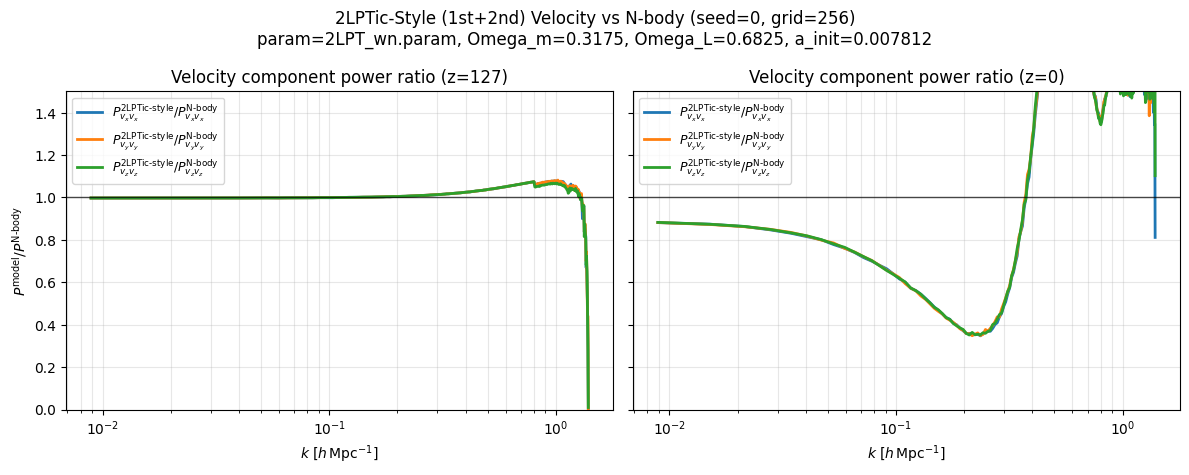

[2LPTic-full] TOTAL 41.60s


In [10]:
from pathlib import Path
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Fully 2LPTic-style velocity (1st + 2nd order) and component-power comparison
LPTIC_SEED = None
LPTIC_GRID = None
LPTIC_PKL_THREADS = 16
LPTIC_LOWK_MAX = 0.10
LPTIC_ASSUME_IC_SQRT_A = True

# 2LPTic constants (allvars.h + set_units)
_HUBBLE_CODE = 3.2407789e-18 * (3.085678e21 / 1.0e5)


def _strip_comment(line: str) -> str:
    if '%' in line:
        line = line[: line.index('%')]
    return line.strip()


def _parse_param_file(path: Path):
    vals = {}
    with path.open('r', encoding='utf-8') as f:
        for raw in f:
            line = _strip_comment(raw)
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                vals[parts[0]] = parts[1]
    return vals


def _find_wn_param(wn_dir: Path) -> Path:
    cands = sorted(wn_dir.glob('*.param'))
    if not cands:
        raise FileNotFoundError(f'No .param found in {wn_dir}')
    preferred = [p for p in cands if p.name.startswith('2LPT_wn')]
    return preferred[0] if preferred else cands[0]


def _load_hdf5_pos_vel(path: Path):
    files = [path] if path.is_file() else sorted(path.glob('*.hdf5'))
    if not files:
        raise FileNotFoundError(f'No hdf5 files found under {path}')
    pos_all, vel_all = [], []
    for fp in files:
        with h5py.File(fp, 'r') as h5:
            g = 'PartType1' if 'PartType1' in h5 else 'PartType0'
            pos_all.append(h5[f'{g}/Coordinates'][:].astype(np.float32))
            vel_all.append(h5[f'{g}/Velocities'][:].astype(np.float32))
    return np.concatenate(pos_all, axis=0), np.concatenate(vel_all, axis=0)


def _cic_weighted(positions, box, grid, weights=None):
    field = np.zeros((grid, grid, grid), dtype=np.float32)
    try:
        import MAS_library as MASL

        pos_c = np.ascontiguousarray(positions.astype(np.float32))
        if weights is None:
            MASL.MA(pos_c, field, float(box), 'CIC', verbose=False)
        else:
            MASL.MA(
                pos_c,
                field,
                float(box),
                'CIC',
                W=np.ascontiguousarray(weights.astype(np.float32)),
                verbose=False,
            )
    except Exception:
        cell = box / grid
        gx = (positions[:, 0] / cell) % grid
        gy = (positions[:, 1] / cell) % grid
        gz = (positions[:, 2] / cell) % grid
        i0 = np.floor(gx).astype(np.int64)
        i1 = (i0 + 1) % grid
        j0 = np.floor(gy).astype(np.int64)
        j1 = (j0 + 1) % grid
        k0 = np.floor(gz).astype(np.int64)
        k1 = (k0 + 1) % grid
        tx = (gx - i0).astype(np.float32)
        ty = (gy - j0).astype(np.float32)
        tz = (gz - k0).astype(np.float32)
        ww = weights.astype(np.float32) if weights is not None else np.ones(len(positions), dtype=np.float32)

        for ii, jj, kk, fac in [
            (i0, j0, k0, (1 - tx) * (1 - ty) * (1 - tz)),
            (i1, j0, k0, tx * (1 - ty) * (1 - tz)),
            (i0, j1, k0, (1 - tx) * ty * (1 - tz)),
            (i0, j0, k1, (1 - tx) * (1 - ty) * tz),
            (i1, j1, k0, tx * ty * (1 - tz)),
            (i1, j0, k1, tx * (1 - ty) * tz),
            (i0, j1, k1, (1 - tx) * ty * tz),
            (i1, j1, k1, tx * ty * tz),
        ]:
            np.add.at(field, (ii, jj, kk), ww * fac)
    return field


def _velocity_component_field(positions, vcomp, box, grid):
    rho = _cic_weighted(positions, box, grid)
    mom = _cic_weighted(positions, box, grid, weights=vcomp)
    rho_safe = np.where(rho > 0, rho, 1.0)
    return (mom / rho_safe).astype(np.float32)


def _pk_field_numpy(field, box_mpc_h):
    n = int(field.shape[0])
    dk = np.fft.rfftn(field.astype(np.float64))
    power = (dk * np.conjugate(dk)).real * (box_mpc_h ** 3) / (n ** 6)

    dx = box_mpc_h / n
    kx = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)
    kkx, kky, kkz = np.meshgrid(kx, ky, kz, indexing='ij')
    kmag = np.sqrt(kkx ** 2 + kky ** 2 + kkz ** 2)

    kf = 2.0 * np.pi / box_mpc_h
    shell = np.rint(kmag / kf).astype(np.int64)
    valid = shell > 0

    shell_flat = shell[valid].ravel()
    p_flat = power[valid].ravel()
    k_flat = kmag[valid].ravel()

    p_sum = np.bincount(shell_flat, weights=p_flat)
    k_sum = np.bincount(shell_flat, weights=k_flat)
    cnt = np.bincount(shell_flat)

    good = cnt > 0
    k_out = k_sum[good] / cnt[good]
    p_out = p_sum[good] / cnt[good]
    return k_out.astype(np.float64), p_out.astype(np.float64)


def _pk_field_3d(field, box_mpc_h):
    try:
        import Pk_library as PKL

        pk_obj = PKL.Pk(
            field.astype(np.float32),
            float(box_mpc_h),
            axis=0,
            MAS='CIC',
            threads=LPTIC_PKL_THREADS,
            verbose=False,
        )
        return np.asarray(pk_obj.k3D, dtype=np.float64), np.asarray(pk_obj.Pk[:, 0], dtype=np.float64)
    except Exception:
        return _pk_field_numpy(field, box_mpc_h)


def _lowk_mean_ratio(k, ratio, kmax):
    m = np.isfinite(ratio) & (k > 0) & (k <= kmax)
    if not np.any(m):
        return np.nan
    return float(np.nanmean(ratio[m]))


def _kgrid(box: float, n: int):
    dx = box / n
    kx = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    ky = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    kz = 2.0 * np.pi * np.fft.rfftfreq(n, d=dx)
    return np.meshgrid(kx, ky, kz, indexing='ij')


def _derivative(field: np.ndarray, axis: int, box: float) -> np.ndarray:
    n = field.shape[0]
    dx = box / n
    k = 2.0 * np.pi * np.fft.fftfreq(n, d=dx)
    if axis == 0:
        phase = (1j * k)[:, None, None]
    elif axis == 1:
        phase = (1j * k)[None, :, None]
    else:
        phase = (1j * k)[None, None, :]
    return np.fft.ifftn(phase * np.fft.fftn(field)).real.astype(np.float32)


def _build_disp2_raw_from_psi1(psi1x: np.ndarray, psi1y: np.ndarray, psi1z: np.ndarray, box: float):
    # Match 2LPTic combination style:
    #   x = q + dis1 - 3/7 dis2_raw
    #   v = dis1*vp1 - 3/7 dis2_raw*vp2
    dxx = _derivative(psi1x, 0, box)
    dyy = _derivative(psi1y, 1, box)
    dzz = _derivative(psi1z, 2, box)
    dxy = _derivative(psi1x, 1, box)
    dxz = _derivative(psi1x, 2, box)
    dyz = _derivative(psi1y, 2, box)

    src = dxx * dyy + dxx * dzz + dyy * dzz - dxy * dxy - dxz * dxz - dyz * dyz
    n = src.shape[0]
    kx, ky, kz = _kgrid(box, n)
    k2 = kx * kx + ky * ky + kz * kz

    src_k = np.fft.rfftn(src)
    phi2_k = np.zeros_like(src_k, dtype=np.complex128)
    m = k2 > 0
    phi2_k[m] = -src_k[m] / k2[m]

    disp2x = np.fft.irfftn(1j * kx * phi2_k, s=(n, n, n)).real.astype(np.float32)
    disp2y = np.fft.irfftn(1j * ky * phi2_k, s=(n, n, n)).real.astype(np.float32)
    disp2z = np.fft.irfftn(1j * kz * phi2_k, s=(n, n, n)).real.astype(np.float32)
    return disp2x, disp2y, disp2z


def _trilinear_interp_vector(q: np.ndarray, fx: np.ndarray, fy: np.ndarray, fz: np.ndarray, box: float) -> np.ndarray:
    n = fx.shape[0]
    cell = box / n

    gx = (q[:, 0] / cell) % n
    gy = (q[:, 1] / cell) % n
    gz = (q[:, 2] / cell) % n

    i0 = np.floor(gx).astype(np.int64)
    j0 = np.floor(gy).astype(np.int64)
    k0 = np.floor(gz).astype(np.int64)

    tx = gx - i0
    ty = gy - j0
    tz = gz - k0

    i1 = (i0 + 1) % n
    j1 = (j0 + 1) % n
    k1 = (k0 + 1) % n

    w000 = (1 - tx) * (1 - ty) * (1 - tz)
    w100 = tx * (1 - ty) * (1 - tz)
    w010 = (1 - tx) * ty * (1 - tz)
    w001 = (1 - tx) * (1 - ty) * tz
    w110 = tx * ty * (1 - tz)
    w101 = tx * (1 - ty) * tz
    w011 = (1 - tx) * ty * tz
    w111 = tx * ty * tz

    def interp(field: np.ndarray):
        return (
            w000 * field[i0, j0, k0]
            + w100 * field[i1, j0, k0]
            + w010 * field[i0, j1, k0]
            + w001 * field[i0, j0, k1]
            + w110 * field[i1, j1, k0]
            + w101 * field[i1, j0, k1]
            + w011 * field[i0, j1, k1]
            + w111 * field[i1, j1, k1]
        )

    out = np.empty((q.shape[0], 3), dtype=np.float32)
    out[:, 0] = interp(fx)
    out[:, 1] = interp(fy)
    out[:, 2] = interp(fz)
    return out


def _omega_a(a, om, ol):
    return om / (om + a * (1.0 - om - ol) + a ** 3 * ol)


def _F_Omega(a, om, ol):
    return _omega_a(a, om, ol) ** 0.6


def _F2_Omega(a, om, ol):
    return 2.0 * (_omega_a(a, om, ol) ** (4.0 / 7.0))


def _hubble_a_code(a, om, ol):
    return _HUBBLE_CODE * np.sqrt(om / a ** 3 + (1.0 - om - ol) / a ** 2 + ol)


# --- Main --------------------------------------------------------------------
t0 = perf_counter()

if 'psiq_rows' not in globals():
    raise RuntimeError('psiq_rows is missing. Run psi1/q_init batch cell first.')
if 'ROOT_BASE' not in globals():
    raise RuntimeError('ROOT_BASE is missing. Run setup cell first.')

ok_rows = [r for r in psiq_rows if not r['error']]
if not ok_rows:
    raise RuntimeError('No successful seed in psiq_rows.')

if LPTIC_SEED is None:
    seed_i = int(ok_rows[0]['seed'])
else:
    target = [r for r in ok_rows if int(r['seed']) == int(LPTIC_SEED)]
    if not target:
        av = sorted(int(r['seed']) for r in ok_rows)
        raise RuntimeError(f'LPTIC_SEED={LPTIC_SEED} unavailable. Available: {av}')
    seed_i = int(target[0]['seed'])

row = [r for r in ok_rows if int(r['seed']) == seed_i][0]
psi1_file = Path(row['psi1_file'])
qinit_file = Path(row['qinit_file'])
wn_dir = psi1_file.parent

param_file = _find_wn_param(wn_dir)
p = _parse_param_file(param_file)
om = float(p['Omega'])
ol = float(p['OmegaLambda'])
if 'InitTime' in p:
    a_init = float(p['InitTime'])
elif 'Redshift' in p:
    a_init = 1.0 / (1.0 + float(p['Redshift']))
else:
    raise KeyError(f'Neither InitTime nor Redshift in {param_file}')

psi = np.load(psi1_file)
qd = np.load(qinit_file)
psi1x = psi['psi1_x'].astype(np.float32)
psi1y = psi['psi1_y'].astype(np.float32)
psi1z = psi['psi1_z'].astype(np.float32)
q_init = qd['q_init'].astype(np.float32)
box = float(np.asarray(psi['box']).ravel()[0])

npart = int(q_init.shape[0])
grid_local = int(round(npart ** (1.0 / 3.0)))
if grid_local ** 3 != npart:
    raise RuntimeError(f'Cannot infer cubic mesh from npart={npart}')
if LPTIC_GRID is None:
    LPTIC_GRID = grid_local

if 'dplus' in psi.files:
    dplus = float(np.asarray(psi['dplus']).ravel()[0])
else:
    # fallback: infer from InitTime (EdS-like for consistency with 2LPTic scaling usage)
    dplus = 1.0 / a_init

print(f'[2LPTic-full] seed={seed_i}, grid={LPTIC_GRID}')
print(f'[2LPTic-full] param={param_file}')
print(f'[2LPTic-full] Omega={om:.6f}, OmegaLambda={ol:.6f}, InitTime={a_init:.8f}, dplus={dplus:.6f}')

print('[2LPTic-full] building 2nd-order displacement raw field ...')
disp2x_raw, disp2y_raw, disp2z_raw = _build_disp2_raw_from_psi1(psi1x, psi1y, psi1z, box)

hubble_init = _hubble_a_code(a_init, om, ol)
hubble_0 = _hubble_a_code(1.0, om, ol)

# 2LPTic storage prefactors in main.c:
# vel_prefac  = InitTime * hubble_a * F_Omega(InitTime) / sqrt(InitTime)
# vel_prefac2 = InitTime * hubble_a * F2_Omega(InitTime) / sqrt(InitTime)
# For comparing to physical peculiar velocity, multiply by sqrt(a).
vp1_127_pec = a_init * hubble_init * _F_Omega(a_init, om, ol)
vp2_127_pec = a_init * hubble_init * _F2_Omega(a_init, om, ol)
vp1_0_pec = 1.0 * hubble_0 * _F_Omega(1.0, om, ol)
vp2_0_pec = 1.0 * hubble_0 * _F2_Omega(1.0, om, ol)

print(f'[2LPTic-full] H(a_init)={hubble_init:.6f}, H(1)={hubble_0:.6f}')
print(f'[2LPTic-full] F1(a_init)={_F_Omega(a_init, om, ol):.6f}, F2(a_init)={_F2_Omega(a_init, om, ol):.6f}')

# z=127: dis = psi1 - 3/7 disp2_raw
print('[2LPTic-full] interpolate v(z=127) ...')
v127_2lptic = _trilinear_interp_vector(
    q_init,
    vp1_127_pec * psi1x - (3.0 / 7.0) * vp2_127_pec * disp2x_raw,
    vp1_127_pec * psi1y - (3.0 / 7.0) * vp2_127_pec * disp2y_raw,
    vp1_127_pec * psi1z - (3.0 / 7.0) * vp2_127_pec * disp2z_raw,
    box,
)
print(f'[2LPTic-full] |v127| rms = {np.sqrt((v127_2lptic ** 2).sum(-1)).mean():.2f} km/s')

# z=0 extension: dis1 scales as dplus, dis2 scales as dplus^2
print('[2LPTic-full] interpolate v(z=0) ...')
v0_2lptic = _trilinear_interp_vector(
    q_init,
    vp1_0_pec * (dplus * psi1x) - (3.0 / 7.0) * vp2_0_pec * (dplus ** 2 * disp2x_raw),
    vp1_0_pec * (dplus * psi1y) - (3.0 / 7.0) * vp2_0_pec * (dplus ** 2 * disp2y_raw),
    vp1_0_pec * (dplus * psi1z) - (3.0 / 7.0) * vp2_0_pec * (dplus ** 2 * disp2z_raw),
    box,
)
print(f'[2LPTic-full] |v0| rms = {np.sqrt((v0_2lptic ** 2).sum(-1)).mean():.2f} km/s')

print('[2LPTic-full] build x(z=0) for Eulerian painting ...')
disp0_2lptic = _trilinear_interp_vector(
    q_init,
    dplus * psi1x - (3.0 / 7.0) * (dplus ** 2) * disp2x_raw,
    dplus * psi1y - (3.0 / 7.0) * (dplus ** 2) * disp2y_raw,
    dplus * psi1z - (3.0 / 7.0) * (dplus ** 2) * disp2z_raw,
    box,
)
x0_2lptic = np.mod(q_init + disp0_2lptic, np.float32(box)).astype(np.float32)

print('[2LPTic-full] loading N-body IC and z=0 velocities ...')
root_i = ROOT_BASE / str(seed_i)
ic_ref = root_i / 'ICs'
snapshot_z0 = root_i / 'snapdir_004'
nb_pos127, nb_vel127 = _load_hdf5_pos_vel(ic_ref)
if LPTIC_ASSUME_IC_SQRT_A:
    nb_vel127 = nb_vel127 * np.float32(np.sqrt(a_init))
nb_pos0, nb_vel0 = _load_hdf5_pos_vel(snapshot_z0)

print(
    f'[2LPTic-full] n(IC)={nb_pos127.shape[0]}, n(z0)={nb_pos0.shape[0]}, '
    f'box={box:.1f} kpc/h'
)

box_mpc_h = box * 1.0e-3
comp_names = ['x', 'y', 'z']
colors = {'x': 'tab:blue', 'y': 'tab:orange', 'z': 'tab:green'}

ratio127 = {}
ratio0 = {}
mask127 = {}
mask0 = {}

print('[2LPTic-full] building component fields and power ratios ...')
for i, name in enumerate(comp_names):
    f127_model = _velocity_component_field(q_init, v127_2lptic[:, i], box, LPTIC_GRID)
    f127_nb = _velocity_component_field(nb_pos127, nb_vel127[:, i], box, LPTIC_GRID)
    f0_model = _velocity_component_field(x0_2lptic, v0_2lptic[:, i], box, LPTIC_GRID)
    f0_nb = _velocity_component_field(nb_pos0, nb_vel0[:, i], box, LPTIC_GRID)

    k127_m, pk127_m = _pk_field_3d(f127_model, box_mpc_h)
    k127_nb, pk127_nb = _pk_field_3d(f127_nb, box_mpc_h)
    k0_m, pk0_m = _pk_field_3d(f0_model, box_mpc_h)
    k0_nb, pk0_nb = _pk_field_3d(f0_nb, box_mpc_h)

    with np.errstate(divide='ignore', invalid='ignore'):
        r127 = np.where(pk127_nb > 1e-30, pk127_m / pk127_nb, np.nan)
        r0 = np.where(pk0_nb > 1e-30, pk0_m / pk0_nb, np.nan)

    m127 = np.isfinite(r127) & (k127_m > 0)
    m0 = np.isfinite(r0) & (k0_m > 0)

    ratio127[name] = (k127_m, r127)
    ratio0[name] = (k0_m, r0)
    mask127[name] = m127
    mask0[name] = m0

    low127 = _lowk_mean_ratio(k127_m, r127, LPTIC_LOWK_MAX)
    low0 = _lowk_mean_ratio(k0_m, r0, LPTIC_LOWK_MAX)
    print(f'[2LPTic-full] {name}: low-k mean ratio z=127={low127:.4f} | z=0={low0:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)

ax = axes[0]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio127[name]
    m = mask127[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm 2LPTic\text{{-}}style}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P^{\rm model}/P^{\rm N\text{-}body}$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=127)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

ax = axes[1]
ax.set_xscale('log')
for name in comp_names:
    k, r = ratio0[name]
    m = mask0[name]
    if np.any(m):
        ax.plot(k[m], r[m], lw=2, color=colors[name], label=rf'$P_{{v_{name}v_{name}}}^{{\rm 2LPTic\text{{-}}style}}/P_{{v_{name}v_{name}}}^{{\rm N\text{{-}}body}}$')
ax.axhline(1.0, color='black', lw=1.0, alpha=0.7)
ax.set_xlabel(r'$k\ [h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylim(0.0, 1.5)
ax.set_title('Velocity component power ratio (z=0)')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)

plt.suptitle(
    f'2LPTic-Style (1st+2nd) Velocity vs N-body (seed={seed_i}, grid={LPTIC_GRID})\n'
    f'param={param_file.name}, Omega_m={om:.4f}, Omega_L={ol:.4f}, a_init={a_init:.6f}'
)
plt.tight_layout()
plt.show()

print(f'[2LPTic-full] TOTAL {perf_counter() - t0:.2f}s')
